# Empirical study notebook

In [1]:
from decision_maker import *
from explainer import estimate_interventional_probability_tabular, UtilityAlignedTabularExplainer
from fairlearn.datasets import fetch_acs_income, fetch_adult
import graphviz
from IPython.display import Image, display
import lime
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from ucimlrepo import fetch_ucirepo
from utils import *
from xgboost import XGBClassifier

/home/alexis/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RANDOM_SEED = 42
used_seeds = [RANDOM_SEED, 2026, 2110]

def evaluate_models(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    y_prob = model.predict_proba(X_test) 
    
    accuracy = accuracy_score(y_test, y_pred)
    
    logloss = log_loss(y_test, y_prob)
    
    if len(np.unique(y_test)) > 2:
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    else:
        roc_auc = roc_auc_score(y_test, y_prob[:, 1])
        
    return accuracy, -logloss, roc_auc

def model_performance(model, X_test, y_test):
    accuracy, logloss, roc_auc = evaluate_models(model, X_test, y_test)
    return {
        "accuracy": accuracy,
        "logloss": -logloss,
        "roc_auc": roc_auc
    }

## Loan Approval dataset

In [3]:
# Loan Approval dataset
loan_df = pd.read_csv("./LoanApproval.csv")
loan_df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [4]:
X_loan = loan_df.drop(columns=["loan_status"])
y_loan = loan_df["loan_status"]

loan_features = X_loan.columns.to_list()
X_train_loan, X_test_loan, y_train_loan, y_test_loan = train_test_split(X_loan, y_loan, test_size=0.2, random_state=RANDOM_SEED)

X_train_loan = X_train_loan.reset_index(drop=True)
X_test_loan = X_test_loan.reset_index(drop=True)
y_train_loan = y_train_loan.reset_index(drop=True)
y_test_loan = y_test_loan.reset_index(drop=True)

categorical_cols = X_loan.select_dtypes(include=['object']).columns.tolist()
loan_categorical_indices = [loan_features.index(col) for col in categorical_cols]
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor_loan = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)], remainder='passthrough')

X_train_processed_loan = pd.DataFrame(preprocessor_loan.fit_transform(X_train_loan), columns=loan_features, index=X_train_loan.index)
X_test_processed_loan = pd.DataFrame(preprocessor_loan.transform(X_test_loan), columns=loan_features, index=X_test_loan.index)

loan_model1 = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
loan_model1.fit(X_train_processed_loan, y_train_loan)

loan_model2 = DecisionTreeClassifier(random_state=RANDOM_SEED)
loan_model2.fit(X_train_processed_loan, y_train_loan)

loan_model3 = XGBClassifier(random_state=RANDOM_SEED, use_label_encoder=False, eval_metric='logloss')
loan_model3.fit(X_train_processed_loan, y_train_loan)

loan_models = [loan_model1, loan_model2, loan_model3]

loan_models.sort(reverse=True,key=lambda model: evaluate_models(model, X_test_processed_loan, y_test_loan))
loan_model = loan_models[0]

loan_class_names = [str(c) for c in sorted(loan_df['loan_status'].unique())]

/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:06:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


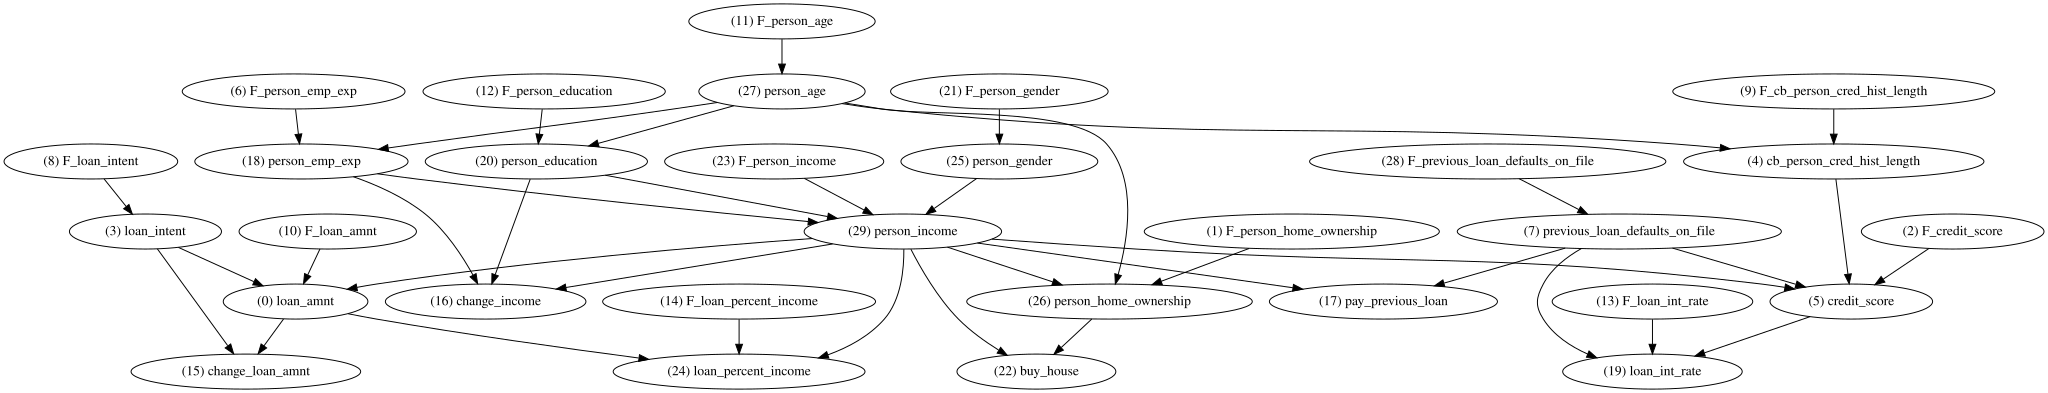

In [5]:
loan_actions = [
    "buy_house",
    "change_loan_amnt", 
    "change_income", 
    "pay_previous_loan"
]

loan_utility_matrix = np.array([[-12, 0], [-7, 0], [-12, 0], [-6, 0]])

loan_causal = CausalModel(features=loan_features, actions=loan_actions)

loan_causal.add_causal_edge("person_age", "person_emp_exp")
loan_causal.add_causal_edge("person_age", "cb_person_cred_hist_length")
loan_causal.add_causal_edge("person_age", "person_education")

loan_causal.add_causal_edge("person_education", "person_income")
loan_causal.add_causal_edge("person_emp_exp", "person_income")

loan_causal.add_causal_edge("person_income", "person_home_ownership")
loan_causal.add_causal_edge("person_age", "person_home_ownership")

loan_causal.add_causal_edge("cb_person_cred_hist_length", "credit_score")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "credit_score")
loan_causal.add_causal_edge("person_income", "credit_score")

loan_causal.add_causal_edge("loan_intent", "loan_amnt")
loan_causal.add_causal_edge("person_income", "loan_amnt")

loan_causal.add_causal_edge("loan_amnt", "loan_percent_income")
loan_causal.add_causal_edge("person_income", "loan_percent_income")

loan_causal.add_causal_edge("credit_score", "loan_int_rate")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "loan_int_rate")
#loan_causal.add_causal_edge("loan_percent_income", "loan_int_rate")
#loan_causal.add_causal_edge("person_home_ownership", "loan_int_rate")

loan_causal.add_causal_edge("person_gender", "person_income")

loan_causal.add_causal_edge("person_income", "buy_house")
loan_causal.add_causal_edge("person_home_ownership", "buy_house")

loan_causal.add_causal_edge("loan_amnt", "change_loan_amnt")
loan_causal.add_causal_edge("loan_intent", "change_loan_amnt")

loan_causal.add_causal_edge("person_income", "change_income")
loan_causal.add_causal_edge("person_education", "change_income")
loan_causal.add_causal_edge("person_emp_exp", "change_income")

loan_causal.add_causal_edge("previous_loan_defaults_on_file", "pay_previous_loan")
loan_causal.add_causal_edge("person_income", "pay_previous_loan")

dag = loan_causal.getDAG()
loan_dot = dag.toDot()
loan_graph = graphviz.Source(loan_dot)
display(loan_graph)

### Function check

In [6]:
prototype_explainer = UtilityAlignedTabularExplainer(
    model = loan_model,
    X_train=X_train_processed_loan,
    features=loan_features,
    actions=loan_actions,
    causal_model=loan_causal,
    utility_matrix=loan_utility_matrix
)
prototype_explanations = prototype_explainer.explain_instance_by_heuristic(X_test_processed_loan.iloc[[0]])
prototype_explanations

{'features': "{'loan_int_rate', 'person_home_ownership'}",
 'prediction probability': array([0.77471197, 0.22528808], dtype=float32),
 'utility score': np.float64(-4.648271799087524),
 'preferrable action': 'pay_previous_loan',
 'information score': np.float64(0.533519853893337)}

### Empirical comparison

In [7]:
loan_lime_explainers = dict()

for seed in used_seeds:
    loan_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_processed_loan.values,
        feature_names=loan_features,
        class_names=loan_class_names, 
#        categorical_features=loan_categorical_indices,
#        discretize_continuous=False,
        random_state=seed
    )
    loan_lime_explainers[seed] = loan_lime_explainer
loan_shap_explainer = None
if isinstance(loan_model, xgb.XGBClassifier):
    loan_shap_explainer = shap.Explainer(loan_model.predict, X_train_processed_loan)
else:
    loan_shap_explainer = shap.Explainer(loan_model)

loan_tester = HeuristicExplainerTester(
    model=loan_model,
    features=loan_features,
    actions=loan_actions,
    causal_model=loan_causal,
    utility_matrix=loan_utility_matrix,
    X_train=X_train_processed_loan,
    y_train=y_train_loan,
    X_test=X_test_processed_loan,
    lime_explainers=loan_lime_explainers,
    shap_explainer=loan_shap_explainer,
    n_samples=20 
)

### Fidelity test

/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:06:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:06:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:06:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:06:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/

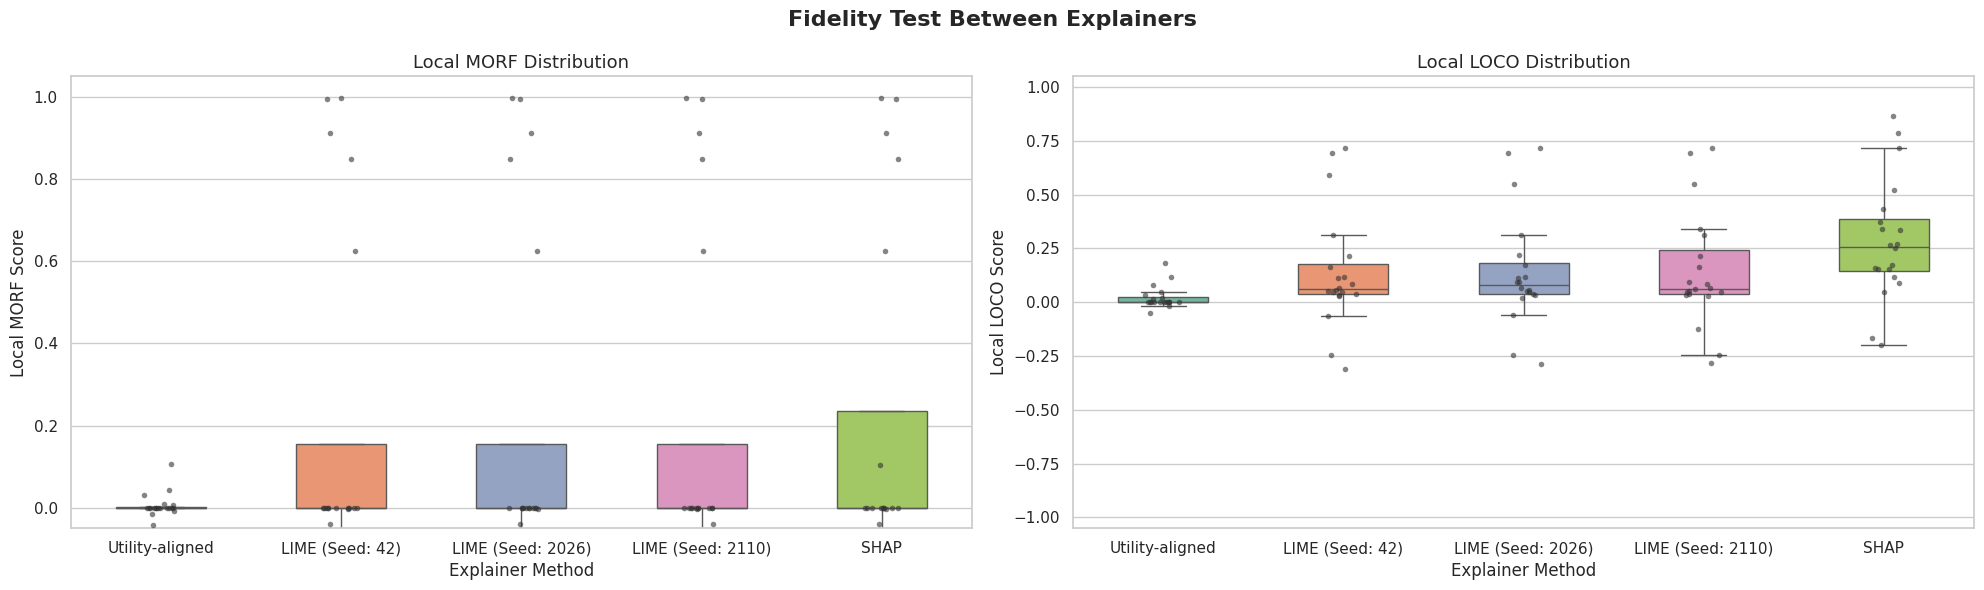

({'Local MORF': [np.float32(0.00021827221),
   np.float32(1.9133091e-05),
   np.float32(-0.0069047213),
   np.float32(-7.1525574e-07),
   np.float32(0.00862509),
   np.float32(8.559227e-05),
   np.float32(1.3113022e-06),
   np.float32(0.0065469146),
   np.float32(0.029849768),
   np.float32(0.044098496),
   np.float32(-0.00052797794),
   np.float32(-0.014751971),
   np.float32(-0.04276067),
   np.float32(6.735325e-06),
   np.float32(2.8789043e-05),
   np.float32(0.0),
   np.float32(5.841255e-06),
   np.float32(0.106434226),
   np.float32(6.7949295e-06),
   np.float32(2.4318695e-05)],
  'Local LOCO': [np.float32(0.016598761),
   np.float32(6.1392784e-06),
   np.float32(0.11526334),
   np.float32(-1.9073486e-06),
   np.float32(-0.051386476),
   np.float32(0.0023357868),
   np.float32(-5.6624413e-06),
   np.float32(0.019266546),
   np.float32(0.18222857),
   np.float32(0.07805568),
   np.float32(0.0005915761),
   np.float32(0.034003556),
   np.float32(0.0461123),
   np.float32(-4.708767e-

In [8]:
loan_tester.fidelity_test(display=True)

### Causality test

/home/alexis/UtilityAlignedExplainer/decision_maker.py:579: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Explainer", y="Causal Consistency Score", palette="Set2", showfliers=False, width=0.5)


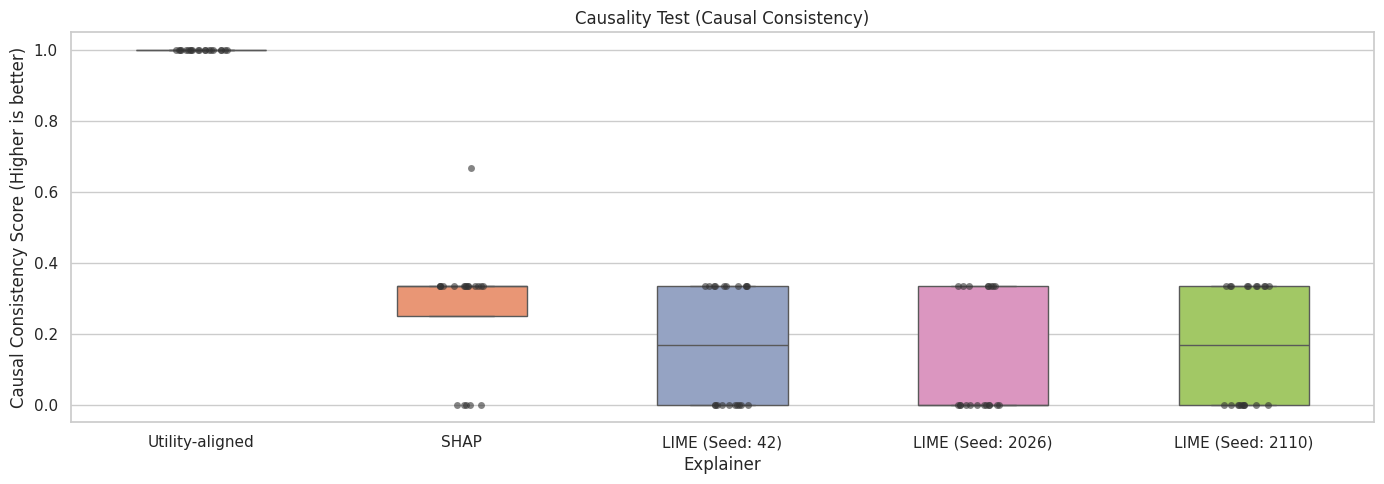

{'Utility-aligned': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'SHAP': [0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.0,
  0.3333333333333333,
  0.3333333333333333,
  0.0,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.0,
  0.6666666666666666,
  0.0,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.0,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333],
 'LIME (Seed: 42)': [0.3333333333333333,
  0.0,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.0,
  0.0,
  0.3333333333333333,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.0,
  0.0,
  0.3333333333333333,
  0.3333333333333333],
 'LIME (Seed: 2026)': [0.0,
  0.0,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333,
  0.0,
  0.0,
  0.3333333333333333,
  0.0,
  0.0,
  0.0

In [9]:
loan_tester.causality_test(display=True)

### Decision utility test

/home/alexis/UtilityAlignedExplainer/decision_maker.py:625: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Explainer", y="Utility Score", palette="Set2", showfliers=False, width=0.5)


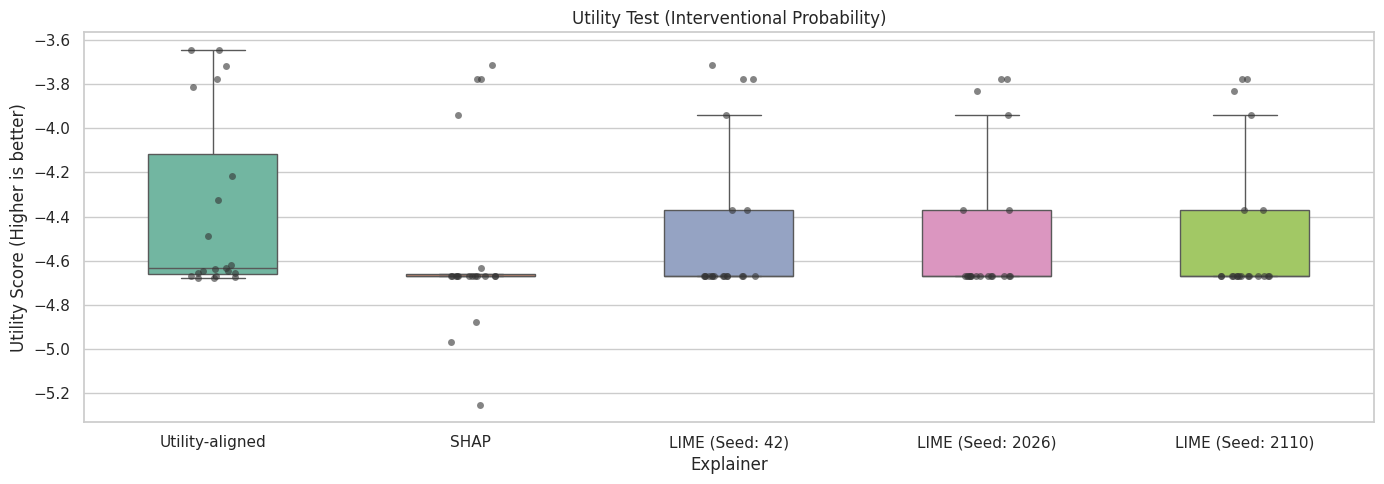

{'Utility-aligned': [np.float64(-4.648271799087524),
  np.float64(-4.657382011413574),
  np.float64(-3.8099030256271362),
  np.float64(-4.217983961105347),
  np.float64(-3.717060685157776),
  np.float64(-4.678516387939453),
  np.float64(-4.678516387939453),
  np.float64(-3.6444404125213623),
  np.float64(-4.636498689651489),
  np.float64(-4.668933033943176),
  np.float64(-4.649151563644409),
  np.float64(-4.488679647445679),
  np.float64(-4.654463768005371),
  np.float64(-4.323818564414978),
  np.float64(-4.618817210197449),
  np.float64(-3.644707202911377),
  np.float64(-4.676644563674927),
  np.float64(-4.634997010231018),
  np.float64(-4.672052621841431),
  np.float64(-3.774996757507324)],
 'SHAP': [np.float64(-5.253318786621094),
  np.float64(-4.668268203735352),
  np.float64(-3.9403828382492065),
  np.float64(-4.668268203735352),
  np.float64(-3.7755085229873657),
  np.float64(-4.668268203735352),
  np.float64(-4.668268203735352),
  np.float64(-3.773623824119568),
  np.float64(-4.

In [10]:
loan_tester.utility_test(display=True)

## Heart Disease

In [11]:
heart_disease = fetch_ucirepo(id=45)
X_heart = heart_disease.data.features.dropna()
y_heart = heart_disease.data.targets.loc[X_heart.index]
X_heart = X_heart.astype(float)
#X_heart = X_heart.reset_index(drop=True)
#y_heart = y_heart.reset_index(drop=True)
#X_heart = X_heart.apply(pd.to_numeric, errors='ignore')

In [12]:
heart_features = X_heart.columns.to_list()

X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(X_heart, y_heart, test_size=0.2, random_state=RANDOM_SEED)

X_train_heart = X_train_heart.reset_index(drop=True)
X_test_heart = X_test_heart.reset_index(drop=True)
y_train_heart = y_train_heart.reset_index(drop=True)
y_test_heart = y_test_heart.reset_index(drop=True)

categorical_cols = X_heart.select_dtypes(include=['object']).columns.tolist()
heart_categorical_indices = [heart_features.index(col) for col in categorical_cols]
#encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

#preprocessor_heart = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)], remainder='passthrough')

#X_train_processed_heart = pd.DataFrame(preprocessor_heart.fit_transform(X_train_heart), columns=heart_features, index=X_train_heart.index)
#X_test_processed_heart = pd.DataFrame(preprocessor_heart.transform(X_test_heart), columns=heart_features, index=X_test_heart.index)

heart_model1 = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
#heart_model1.fit(X_train_processed_heart, y_train_heart)
heart_model1.fit(X_train_heart, y_train_heart)

heart_model2 = DecisionTreeClassifier(random_state=RANDOM_SEED)
#heart_model2.fit(X_train_processed_heart, y_train_heart)
heart_model2.fit(X_train_heart, y_train_heart)

heart_model3 = XGBClassifier(random_state=RANDOM_SEED, use_label_encoder=False, eval_metric='logloss')
#heart_model3.fit(X_train_processed_heart, y_train_heart)
heart_model3.fit(X_train_heart, y_train_heart)

heart_models = [heart_model1, heart_model2, heart_model3]

#heart_models.sort(reverse=True,key=lambda model: evaluate_models(model, X_test_processed_heart, y_test_heart))
heart_models.sort(reverse=True,key=lambda model: evaluate_models(model, X_test_heart, y_test_heart))
heart_model = heart_models[0]

heart_class_names = [str(c) for c in sorted(np.unique(y_heart.values))]

/home/alexis/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:07:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [13]:
def add_pathophysiology_edges(causal_model):
    causal_model.add_causal_edge('age', 'trestbps')
    causal_model.add_causal_edge('age', 'chol')
    causal_model.add_causal_edge('age', 'thalach')

    causal_model.add_causal_edge('sex', 'chol')
    causal_model.add_causal_edge('sex', 'thal')
    
    causal_model.add_causal_edge('trestbps', 'cp')
    causal_model.add_causal_edge('chol', 'cp')
    causal_model.add_causal_edge('fbs', 'cp')
    causal_model.add_causal_edge('cp', 'exang')
    
    causal_model.add_causal_edge('chol', 'ca')
    causal_model.add_causal_edge('trestbps', 'restecg')
    causal_model.add_causal_edge('thalach', 'oldpeak')
    causal_model.add_causal_edge('oldpeak', 'slope')

### Patient-oriented explainer

In [14]:
patient_actions = ['change_diet', 'increase_physical_activity', 'monitor_vitals_at_home', 'seek_immediate_care']

patient_utility_matrix = np.array([
    [ 0,  5,  5,   2,   1],  # change_diet
    [ 2,  5, -5, -10, -15],  # increase_physical_activity
    [-1,  2,  5,   5,   2],  # monitor_vitals_at_home
    [-5, -2,  2,  10,  15]   # seek_immediate_care
])

patient_causal = CausalModel(features=heart_features, actions=patient_actions)
add_pathophysiology_edges(patient_causal)

patient_causal.add_causal_edge('chol', 'change_diet')
patient_causal.add_causal_edge('trestbps', 'change_diet')
patient_causal.add_causal_edge('fbs', 'change_diet')

patient_causal.add_causal_edge('age', 'increase_physical_activity')
patient_causal.add_causal_edge('thalach', 'increase_physical_activity')
patient_causal.add_causal_edge('cp', 'increase_physical_activity')

patient_causal.add_causal_edge('trestbps', 'monitor_vitals_at_home')
patient_causal.add_causal_edge('fbs', 'monitor_vitals_at_home')

patient_causal.add_causal_edge('cp', 'seek_immediate_care')
patient_causal.add_causal_edge('exang', 'seek_immediate_care')

In [15]:
patient_lime_explainers = dict()

for seed in used_seeds:
    patient_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_heart.values,
        feature_names=heart_features,
        class_names=heart_class_names, 
#        categorical_features=heart_categorical_indices,
#        discretize_continuous=False,
        mode='classification',
        random_state=seed
    )
    patient_lime_explainers[seed] = patient_lime_explainer
patient_shap_explainer = None
if isinstance(heart_model, xgb.XGBClassifier):
    patient_shap_explainer = shap.Explainer(heart_model.predict, X_train_heart)
else:
    patient_shap_explainer = shap.Explainer(heart_model)

patient_tester = HeuristicExplainerTester(
    model=heart_model,
    features=heart_features,
    actions=patient_actions,
    causal_model=patient_causal,
    utility_matrix=patient_utility_matrix,
    X_train=X_train_heart,
    y_train=y_train_heart,
    X_test=X_test_heart,
    lime_explainers=patient_lime_explainers,
    shap_explainer=patient_shap_explainer,
    n_samples=20 
)

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alexis/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-ve

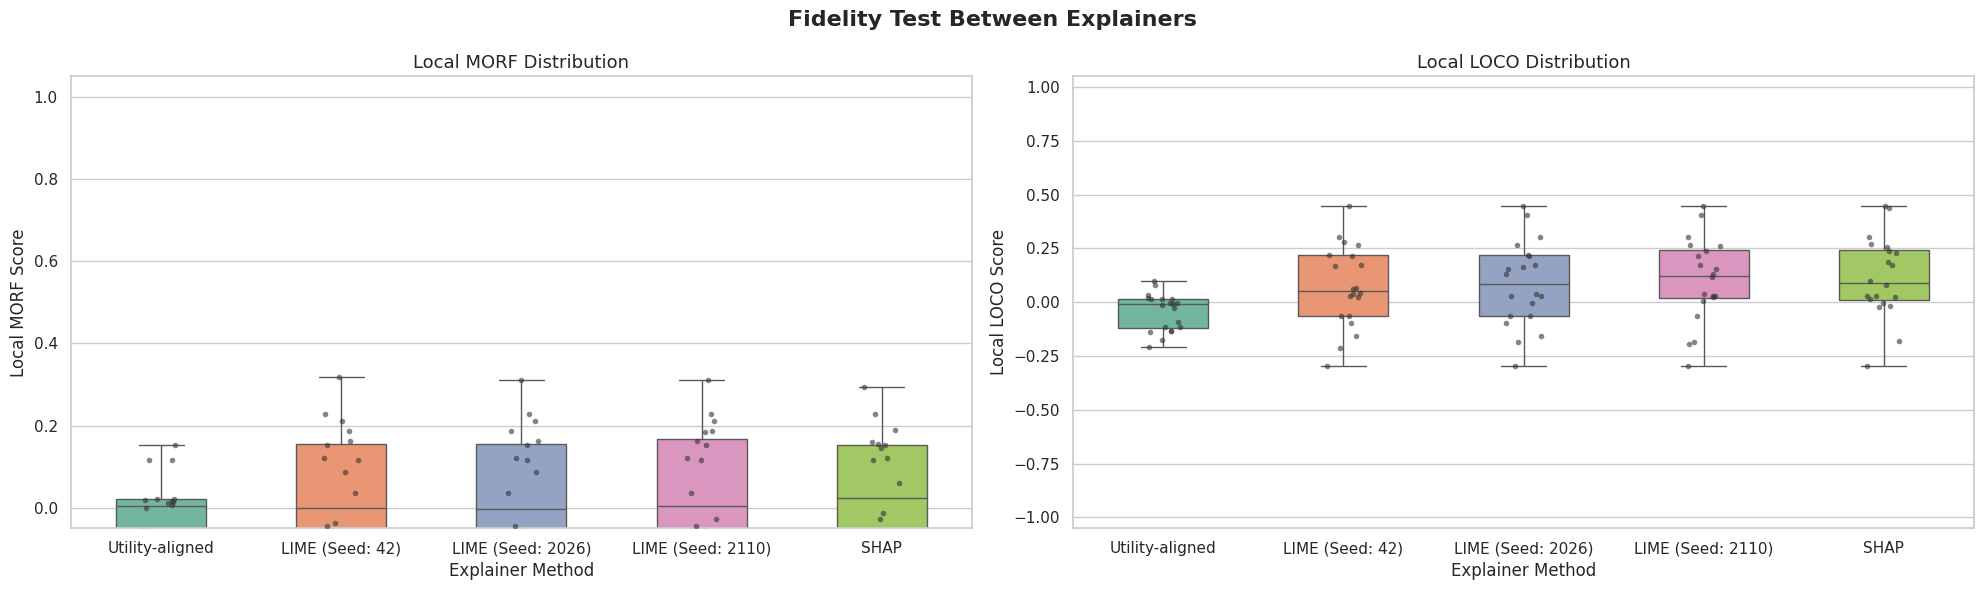

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

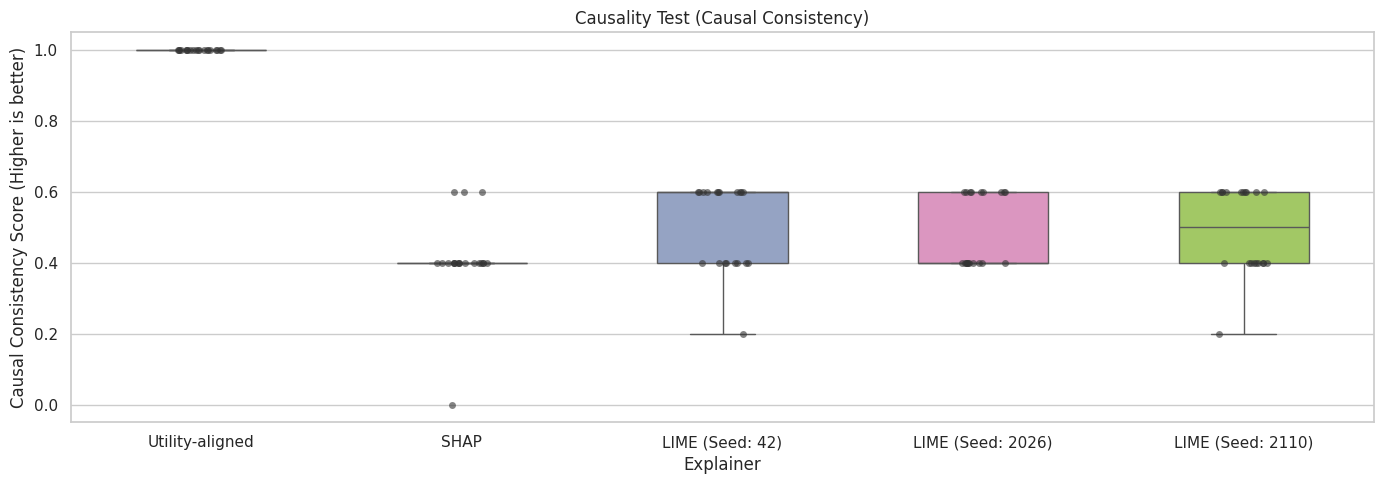

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

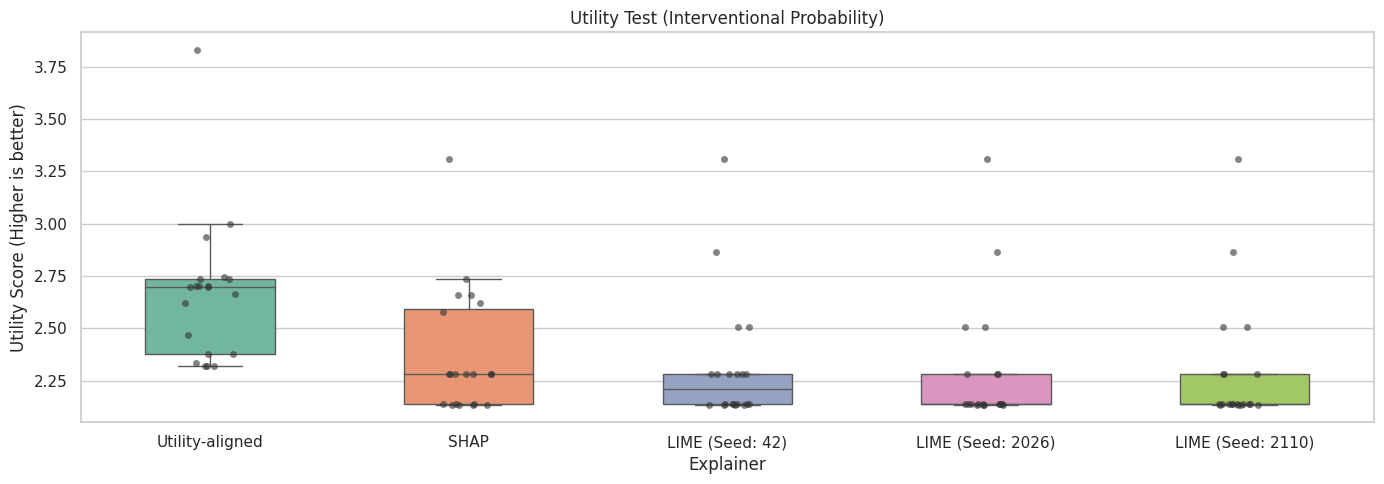

{'Utility-aligned': [np.float64(2.37945328742569),
  np.float64(2.7369429896735644),
  np.float64(2.320382219046106),
  np.float64(3.8288755856008545),
  np.float64(2.3203822190461065),
  np.float64(2.703682915148362),
  np.float64(2.695626038660245),
  np.float64(2.997805941442513),
  np.float64(2.742561363490307),
  np.float64(2.46796602691914),
  np.float64(2.6615977285818335),
  np.float64(2.334978788122338),
  np.float64(2.3794532874256906),
  np.float64(2.703682915148362),
  np.float64(2.695626038660245),
  np.float64(2.320382219046106),
  np.float64(2.619552610420132),
  np.float64(2.7015598563833914),
  np.float64(2.937921415776929),
  np.float64(2.7369429896735644)],
 'SHAP': [np.float64(2.1357350057286673),
  np.float64(2.579804987216176),
  np.float64(2.281794366960995),
  np.float64(3.3076519974631853),
  np.float64(2.281794366960995),
  np.float64(2.281794366960995),
  np.float64(2.6589883650516435),
  np.float64(2.2817943669609955),
  np.float64(2.619552610420132),
  np.f

In [16]:
patient_tester.fidelity_test(display=True)
patient_tester.causality_test(display=True)
patient_tester.utility_test(display=True)

### Doctor-oriented explainer

In [17]:
doctor_actions = ['prescribe_statins', 'prescribe_beta_blockers', 'order_angiography', 'refer_to_surgery']

doctor_utility_matrix = np.array([
    [-2,  5,  5,   3,   1],  # prescribe_statins
    [-3,  3,  6,   5,   2],  # prescribe_beta_blockers
    [-5,  0,  6,   8,  10],  # order_angiography
    [-10,-5, -2,  10,  15]   # refer_to_surgery
])

doctor_causal = CausalModel(features=heart_features, actions=doctor_actions)
add_pathophysiology_edges(doctor_causal)

doctor_causal.add_causal_edge('chol', 'prescribe_statins')
doctor_causal.add_causal_edge('age', 'prescribe_statins')

doctor_causal.add_causal_edge('trestbps', 'prescribe_beta_blockers')
doctor_causal.add_causal_edge('thalach', 'prescribe_beta_blockers')
doctor_causal.add_causal_edge('oldpeak', 'prescribe_beta_blockers')

doctor_causal.add_causal_edge('cp', 'order_angiography')
doctor_causal.add_causal_edge('slope', 'order_angiography')
doctor_causal.add_causal_edge('thal', 'order_angiography')

doctor_causal.add_causal_edge('ca', 'refer_to_surgery')
doctor_causal.add_causal_edge('thal', 'refer_to_surgery')
doctor_causal.add_causal_edge('oldpeak', 'refer_to_surgery')

In [18]:
doctor_lime_explainers = dict()

for seed in used_seeds:
    doctor_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_heart.values,
        feature_names=heart_features,
        class_names=heart_class_names, 
#        categorical_features=heart_categorical_indices,
#        discretize_continuous=False,
        mode='classification',
        random_state=seed
    )
    doctor_lime_explainers[seed] = doctor_lime_explainer
doctor_shap_explainer = None
if isinstance(heart_model, xgb.XGBClassifier):
    doctor_shap_explainer = shap.Explainer(heart_model.predict, X_train_heart)
else:
    doctor_shap_explainer = shap.Explainer(heart_model)


doctor_tester = HeuristicExplainerTester(
    model=heart_model,
    features=heart_features,
    actions=doctor_actions,
    causal_model=doctor_causal,
    utility_matrix=doctor_utility_matrix,
    X_train=X_train_heart,
    y_train=y_train_heart,
    X_test=X_test_heart,
    lime_explainers=doctor_lime_explainers,
    shap_explainer=doctor_shap_explainer,
    n_samples=20 
)

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alexis/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-ve

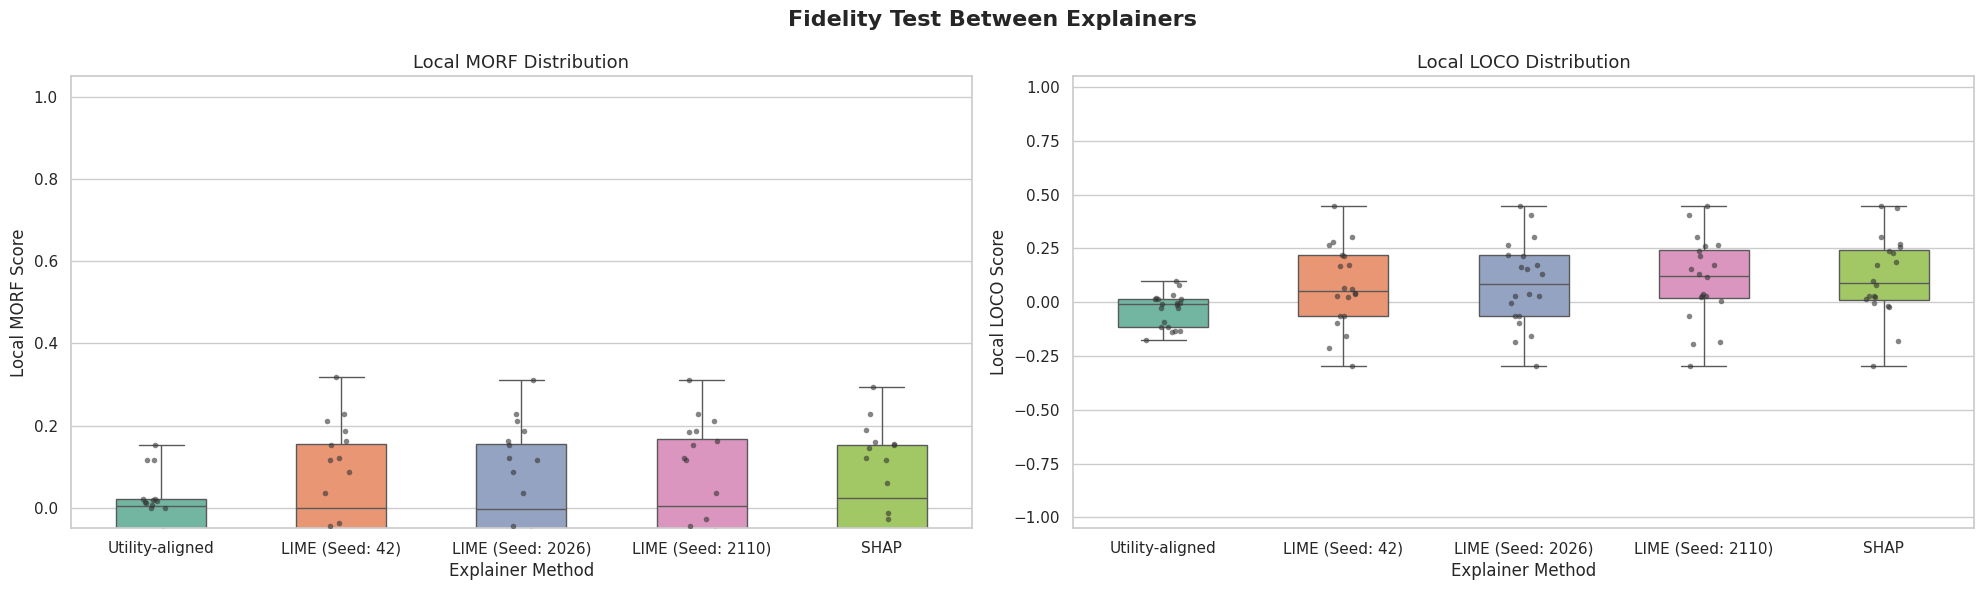

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

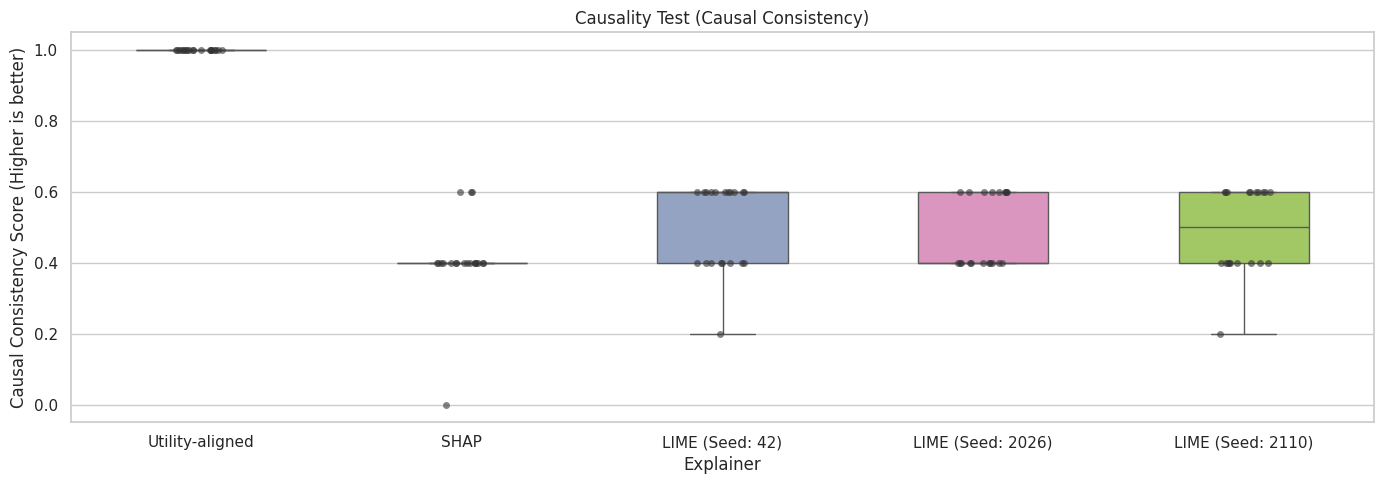

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

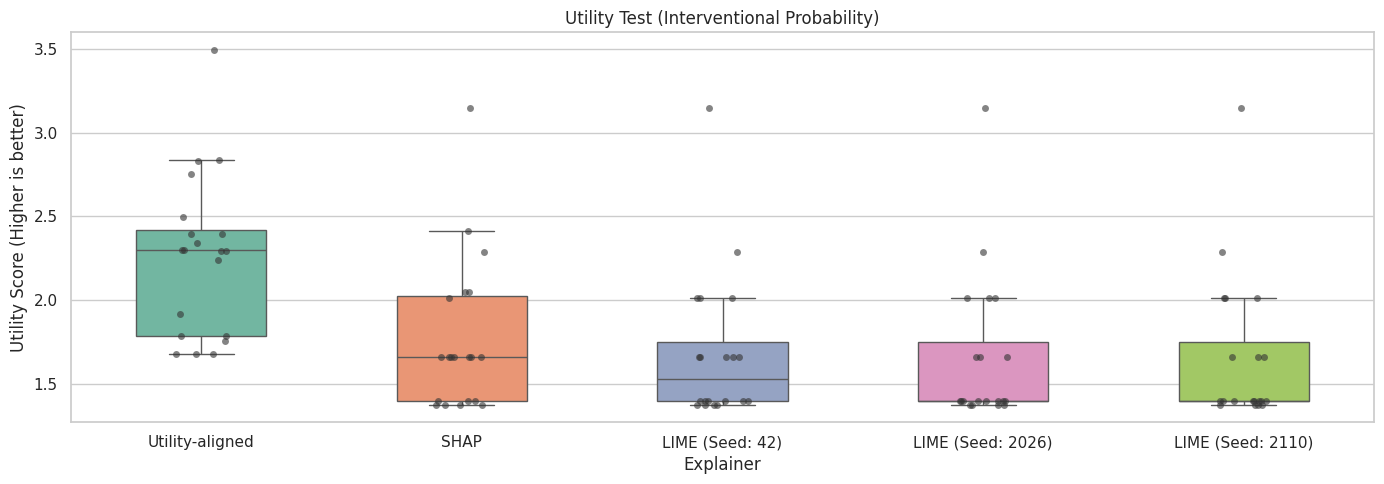

{'Utility-aligned': [np.float64(1.7874994593529288),
  np.float64(2.299759333316759),
  np.float64(1.6793298693633079),
  np.float64(3.491740340745955),
  np.float64(1.6793298693633076),
  np.float64(2.2945903665739102),
  np.float64(2.395822836257005),
  np.float64(2.8340825820921545),
  np.float64(2.8296185736738604),
  np.float64(1.9211291917456133),
  np.float64(2.4961329127516243),
  np.float64(1.7598540821580553),
  np.float64(1.7874994593529288),
  np.float64(2.2945903665739102),
  np.float64(2.3958228362570053),
  np.float64(1.6793298693633076),
  np.float64(2.239794276878313),
  np.float64(2.34426345558147),
  np.float64(2.750363962321526),
  np.float64(2.299759333316759)],
 'SHAP': [np.float64(1.378558937759381),
  np.float64(2.048917740480887),
  np.float64(1.6609443469913174),
  np.float64(3.148256720553838),
  np.float64(1.6609443469913174),
  np.float64(1.378558937759381),
  np.float64(1.6609443469913172),
  np.float64(1.6609443469913174),
  np.float64(2.4145610649886957)

In [19]:
doctor_tester.fidelity_test(display=True)
doctor_tester.causality_test(display=True)
doctor_tester.utility_test(display=True)

## Adult Income dataset

In [20]:
X_adult, y_adult = shap.datasets.adult()
X_adult.columns = X_adult.columns.str.replace(r'[\s\-]+', '_', regex=True)
X_adult = X_adult.astype(float)
y_adult = y_adult.astype(int)

In [21]:
adult_features = X_adult.columns.to_list()
X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(X_adult, y_adult, test_size=0.2, random_state=RANDOM_SEED)

X_train_adult = X_train_adult.reset_index(drop=True)
X_test_adult = X_test_adult.reset_index(drop=True)

adult_model1 = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
adult_model1.fit(X_train_adult, y_train_adult)

adult_model2 = DecisionTreeClassifier(random_state=RANDOM_SEED)
adult_model2.fit(X_train_adult, y_train_adult)

adult_model3 = XGBClassifier(random_state=RANDOM_SEED, use_label_encoder=False, eval_metric='logloss')
adult_model3.fit(X_train_adult, y_train_adult)

adult_class_names = np.unique(y_adult)

/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:10:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Causal case 1: When sensitive features affect the education opportunity and the choice of job

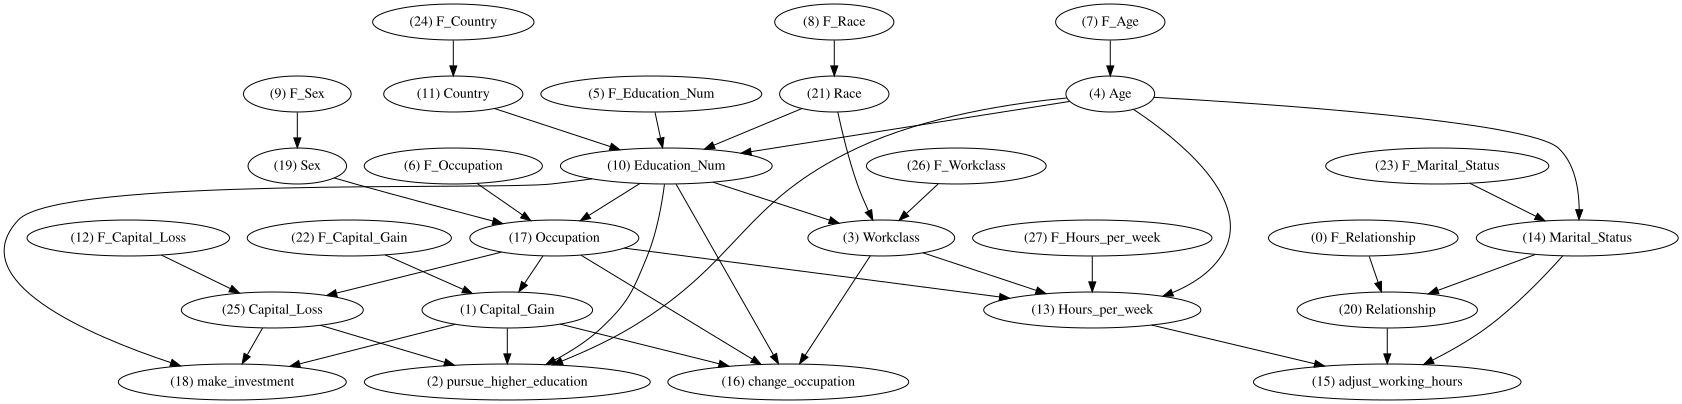

In [22]:
adult_actions = [
    'pursue_higher_education',
    'change_occupation',
    'adjust_working_hours',
    'make_investment'
]

adult_utility_matrix = np.array([
    [-5, 10],  # pursue_higher_education
    [-3,  7],  # change_occupation
    [-1,  4],  # adjust_working_hours
    [-4,  8]   # make_investment
])

adult_causal = CausalModel(features=adult_features, actions=adult_actions)

adult_causal.add_causal_edge('Age', 'Education_Num')
adult_causal.add_causal_edge('Age', 'Marital_Status')
adult_causal.add_causal_edge('Age', 'Hours_per_week')

adult_causal.add_causal_edge('Country', 'Education_Num')
adult_causal.add_causal_edge('Race', 'Education_Num')
adult_causal.add_causal_edge('Sex', 'Occupation')

adult_causal.add_causal_edge('Education_Num', 'Occupation')
adult_causal.add_causal_edge('Education_Num', 'Workclass')

adult_causal.add_causal_edge('Marital_Status', 'Relationship')

adult_causal.add_causal_edge('Occupation', 'Hours_per_week')
adult_causal.add_causal_edge('Occupation', 'Capital_Gain')
adult_causal.add_causal_edge('Occupation', 'Capital_Loss')

adult_causal.add_causal_edge('Race', 'Workclass')

adult_causal.add_causal_edge('Workclass', 'Hours_per_week')

adult_causal.add_causal_edge('Age', 'pursue_higher_education')
adult_causal.add_causal_edge('Education_Num', 'pursue_higher_education')
adult_causal.add_causal_edge('Capital_Gain', 'pursue_higher_education')
adult_causal.add_causal_edge('Capital_Loss', 'pursue_higher_education')

adult_causal.add_causal_edge('Occupation', 'change_occupation')
adult_causal.add_causal_edge('Education_Num', 'change_occupation')
adult_causal.add_causal_edge('Workclass', 'change_occupation')
adult_causal.add_causal_edge('Capital_Gain', 'change_occupation')

adult_causal.add_causal_edge('Hours_per_week', 'adjust_working_hours')
adult_causal.add_causal_edge('Marital_Status', 'adjust_working_hours')
adult_causal.add_causal_edge('Relationship', 'adjust_working_hours')

adult_causal.add_causal_edge('Capital_Gain', 'make_investment')
adult_causal.add_causal_edge('Capital_Loss', 'make_investment')
adult_causal.add_causal_edge('Education_Num', 'make_investment')

dag = adult_causal.getDAG()
adult_dot = dag.toDot()
adult_graph = graphviz.Source(adult_dot)

display(adult_graph)

#### Model 1: `RandomForestClassifier`

In [23]:
adult_lime_explainers = dict()

for seed in used_seeds:
    adult_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_adult.values,
        feature_names=adult_features,
        class_names=adult_class_names, 
#        categorical_features=adult_categorical_indices,
#        discretize_continuous=False,
        random_state=seed
    )
    adult_lime_explainers[seed] = adult_lime_explainer
adult_shap_explainer = shap.Explainer(adult_model1)

adult_tester1 = HeuristicExplainerTester(
    model=adult_model1,
    features=adult_features,
    actions=adult_actions,
    causal_model=adult_causal,
    utility_matrix=adult_utility_matrix,
    X_train=X_train_adult,
    y_train=y_train_adult,
    X_test=X_test_adult,
    lime_explainers=adult_lime_explainers,
    shap_explainer=adult_shap_explainer,
    n_samples=20 
)

model_performance(adult_model1, X_test_adult, y_test_adult)

{'accuracy': 0.8378627360663289,
 'logloss': 0.3375156001104846,
 'roc_auc': 0.9203442942589801}

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

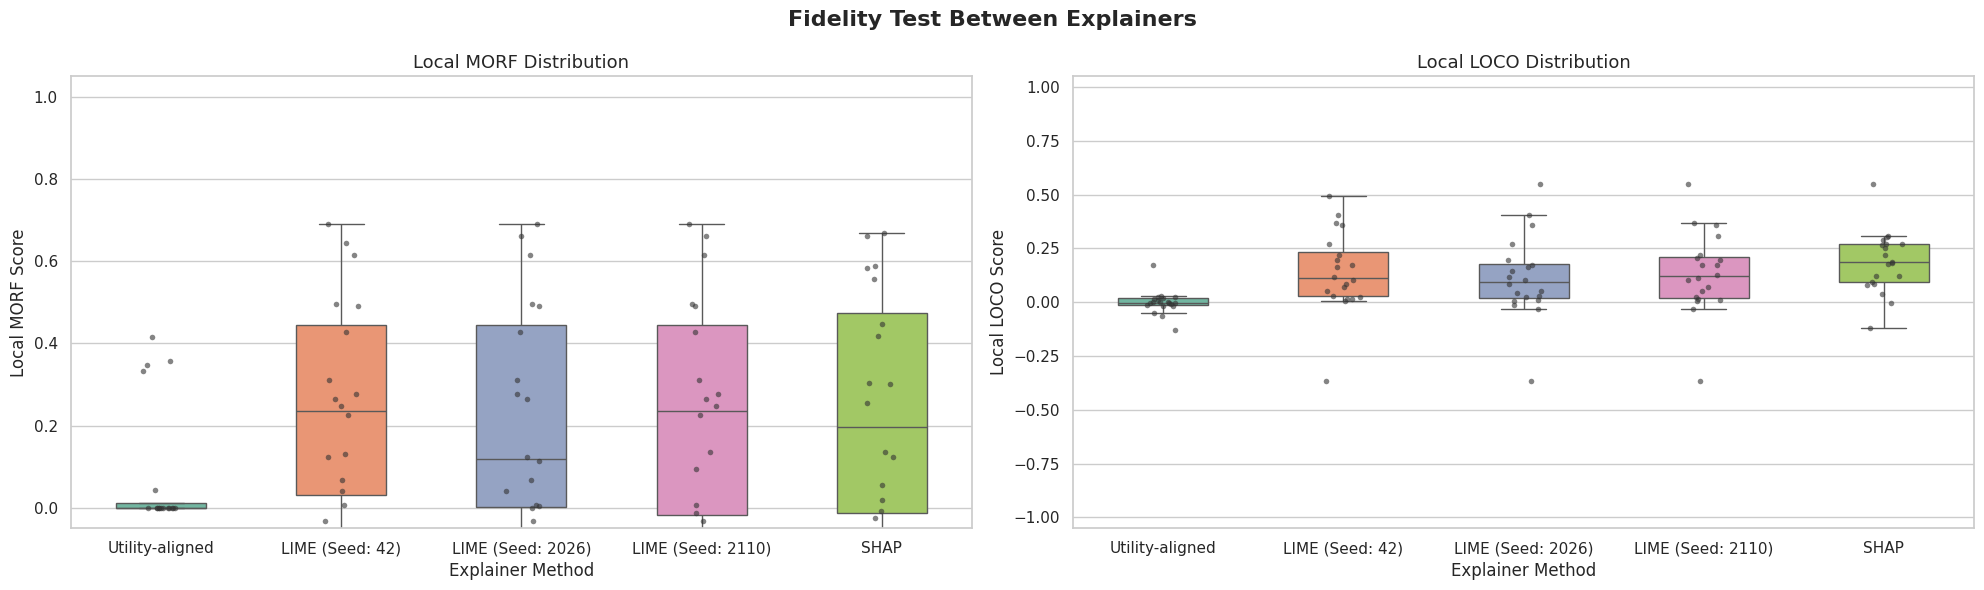

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

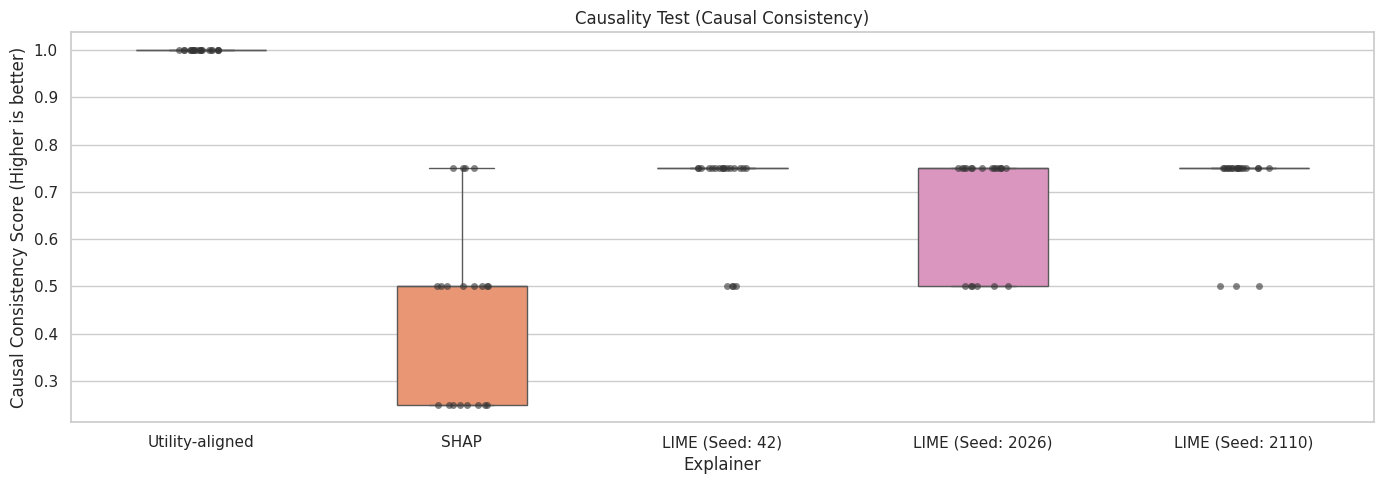

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

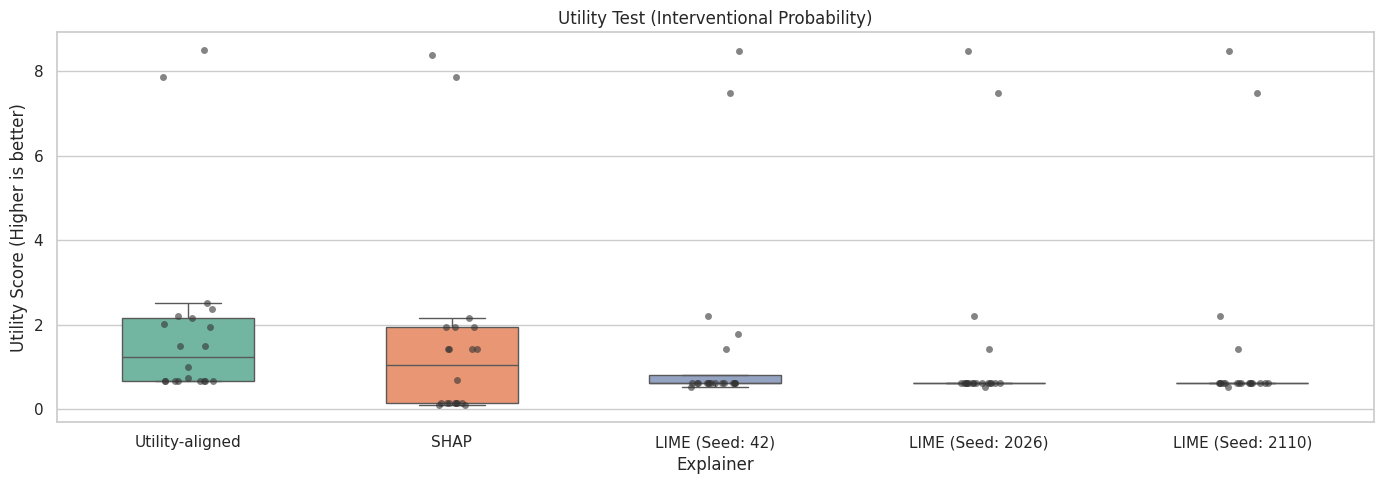

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

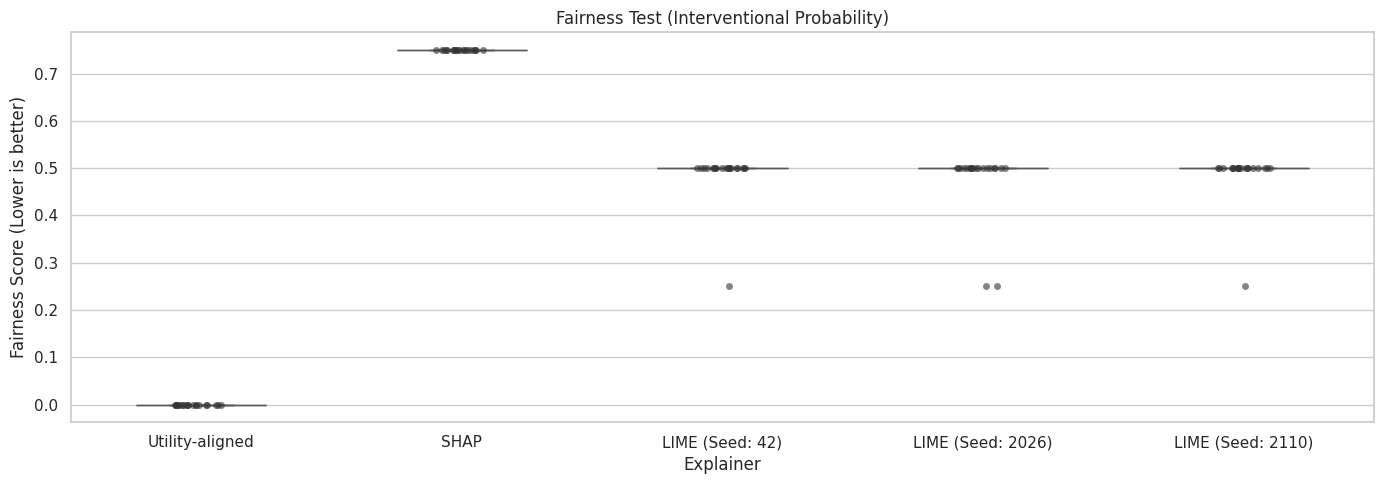

{'fidelity': ({'Local MORF': [np.float64(0.0),
    np.float64(0.33344936175107304),
    np.float64(0.41519621793870737),
    np.float64(0.0),
    np.float64(-0.23087648162603858),
    np.float64(0.3480666699546262),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.04228123877081369),
    np.float64(-0.0018331679368903675),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(-0.0914770429017363),
    np.float64(-0.29493139952323755),
    np.float64(0.0),
    np.float64(-0.0019078436169740476),
    np.float64(0.35678260270961704),
    np.float64(0.0),
    np.float64(0.0)],
   'Local LOCO': [np.float64(-0.002023118575324223),
    np.float64(0.02100582414795127),
    np.float64(0.026326269560550952),
    np.float64(-0.003993642235529782),
    np.float64(-0.13098693095235636),
    np.float64(0.001391847355864062),
    np.float64(-0.009867282656360055),
    np.float64(-0.00035438617296068564),
    np.float64(0.01729769230272893),
    np.float64(0.027761744

In [24]:
adult_tester1.do_all_tests(["Sex", "Race", "Country", "Marital_status"], display=True)

#### Model 2: `DecisionTreeClassifier`

In [25]:
adult_lime_explainers = dict()

for seed in used_seeds:
    adult_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_adult.values,
        feature_names=adult_features,
        class_names=adult_class_names, 
#        categorical_features=adult_categorical_indices,
#        discretize_continuous=False,
        random_state=seed
    )
    adult_lime_explainers[seed] = adult_lime_explainer
adult_shap_explainer = shap.Explainer(adult_model2)

adult_tester2 = HeuristicExplainerTester(
    model=adult_model2,
    features=adult_features,
    actions=adult_actions,
    causal_model=adult_causal,
    utility_matrix=adult_utility_matrix,
    X_train=X_train_adult,
    y_train=y_train_adult,
    X_test=X_test_adult,
    lime_explainers=adult_lime_explainers,
    shap_explainer=adult_shap_explainer,
    n_samples=20 
)

model_performance(adult_model2, X_test_adult, y_test_adult)

{'accuracy': 0.8220482112697681,
 'logloss': 5.818243152576052,
 'roc_auc': 0.7777645899306559}

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted w

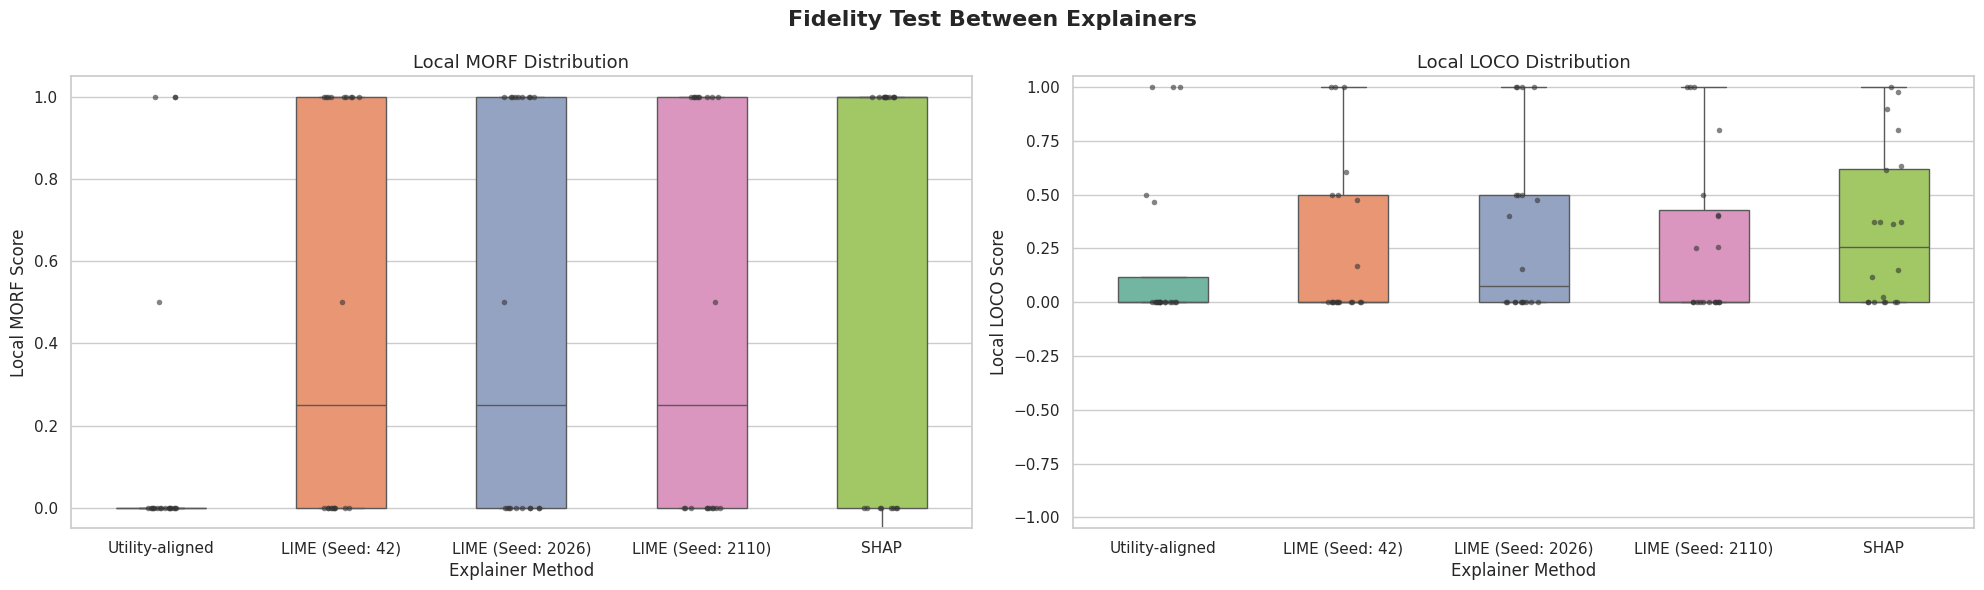

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted w

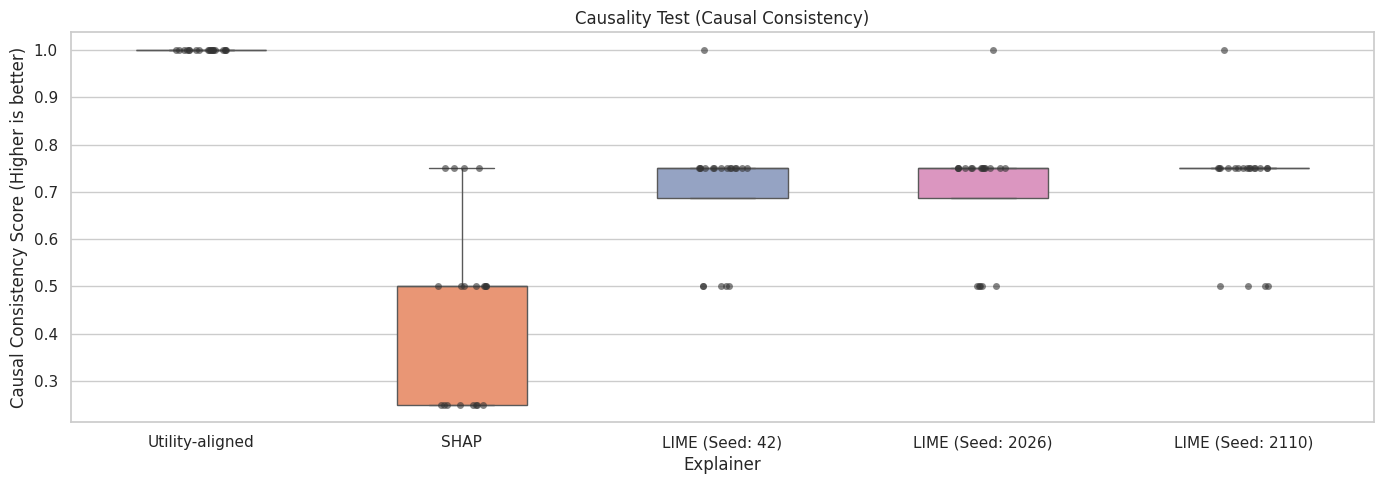

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted w

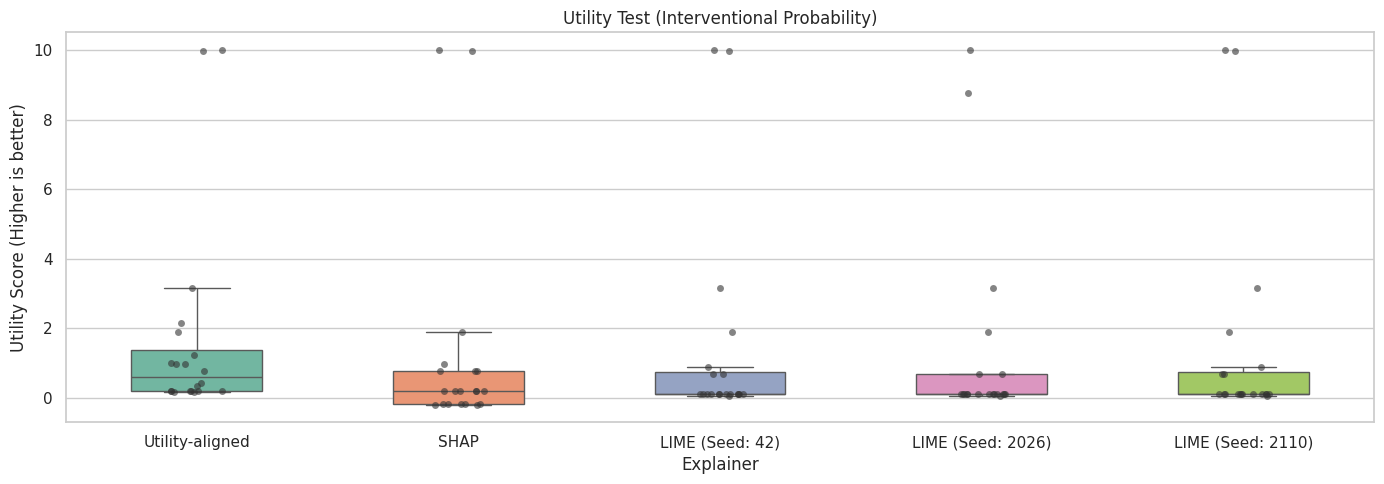

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted w

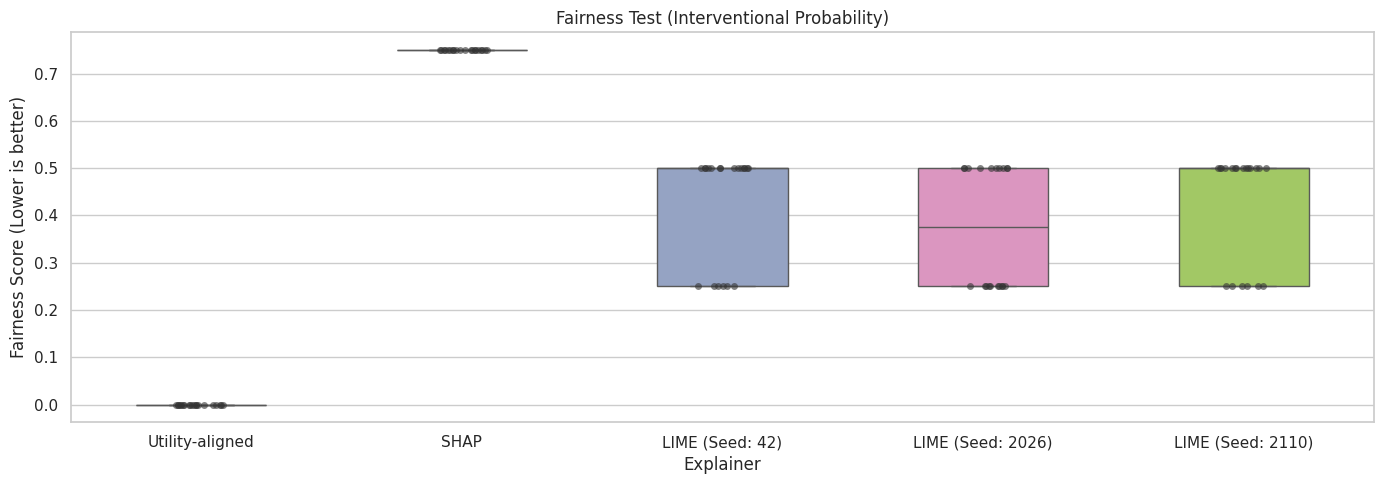

{'fidelity': ({'Local MORF': [np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(1.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.5),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(1.0),
    np.float64(1.0),
    np.float64(0.0)],
   'Local LOCO': [np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(1.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.4666666666666667),
    np.float64(1.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.5),
    np.float64(0.0),
    np.float64(1.0),
    np.float64(0.0)]},
  {'LIME (Seed: 42)': {'Local MORF': [np.float64(0.0),
     np.float64(1.0),
     np.float64(1.0),
   

In [26]:
adult_tester2.do_all_tests(["Sex", "Race", "Country", "Marital_status"], display=True)

#### Model 3: `XGBClassifier`

In [27]:
adult_lime_explainers = dict()

for seed in used_seeds:
    adult_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_adult.values,
        feature_names=adult_features,
        class_names=adult_class_names, 
#        categorical_features=adult_categorical_indices,
#        discretize_continuous=False,
        random_state=seed
    )
    adult_lime_explainers[seed] = adult_lime_explainer
adult_shap_explainer = shap.Explainer(adult_model3.predict, X_train_adult)

adult_tester3 = HeuristicExplainerTester(
    model=adult_model3,
    features=adult_features,
    actions=adult_actions,
    causal_model=adult_causal,
    utility_matrix=adult_utility_matrix,
    X_train=X_train_adult,
    y_train=y_train_adult,
    X_test=X_test_adult,
    lime_explainers=adult_lime_explainers,
    shap_explainer=adult_shap_explainer,
    n_samples=20 
)

model_performance(adult_model3, X_test_adult, y_test_adult)

{'accuracy': 0.8759404268386304,
 'logloss': 0.275005520020763,
 'roc_auc': 0.9291614040501903}

/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:16:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:16:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:16:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:16:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/

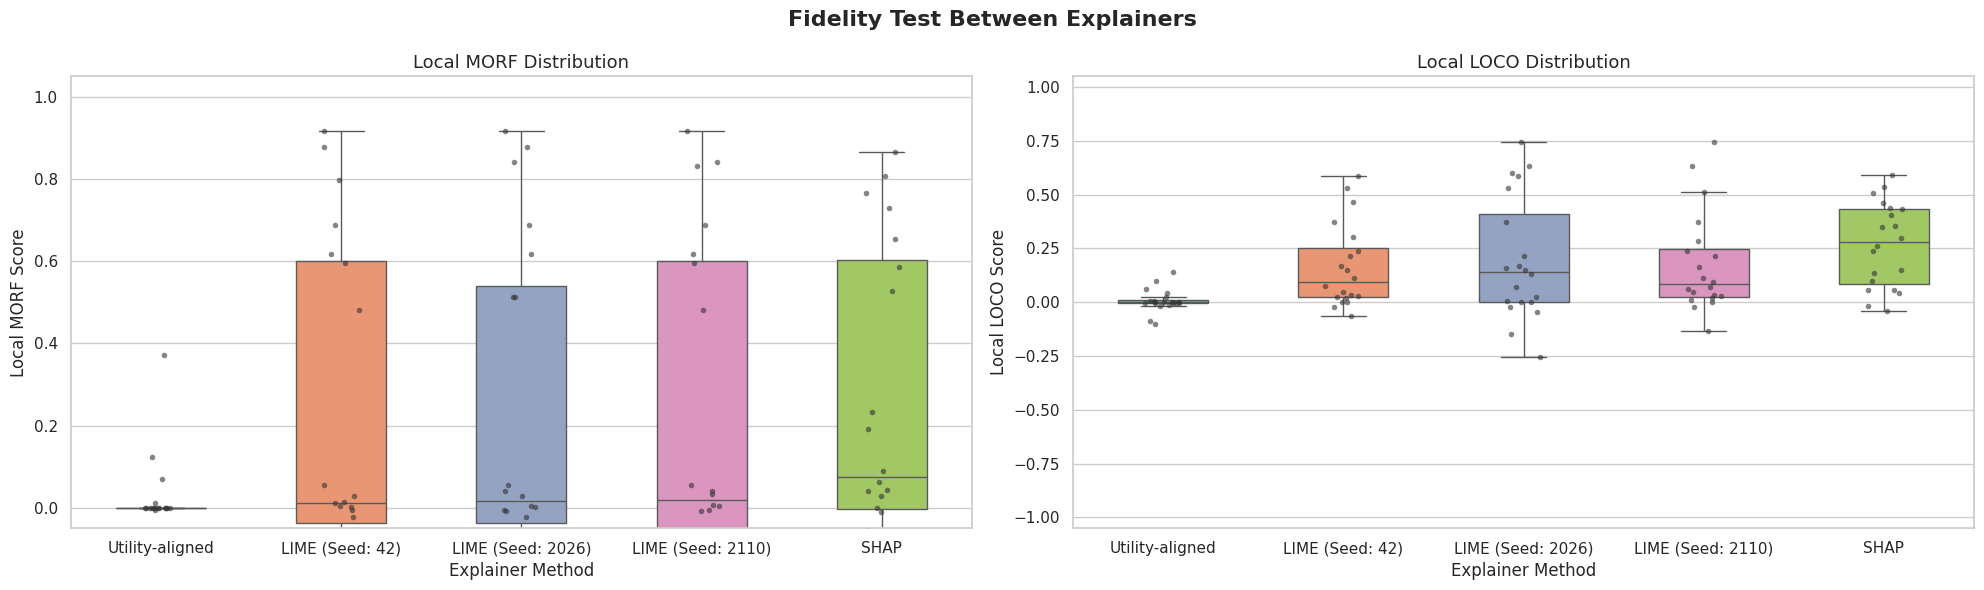

/home/alexis/UtilityAlignedExplainer/decision_maker.py:579: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Explainer", y="Causal Consistency Score", palette="Set2", showfliers=False, width=0.5)


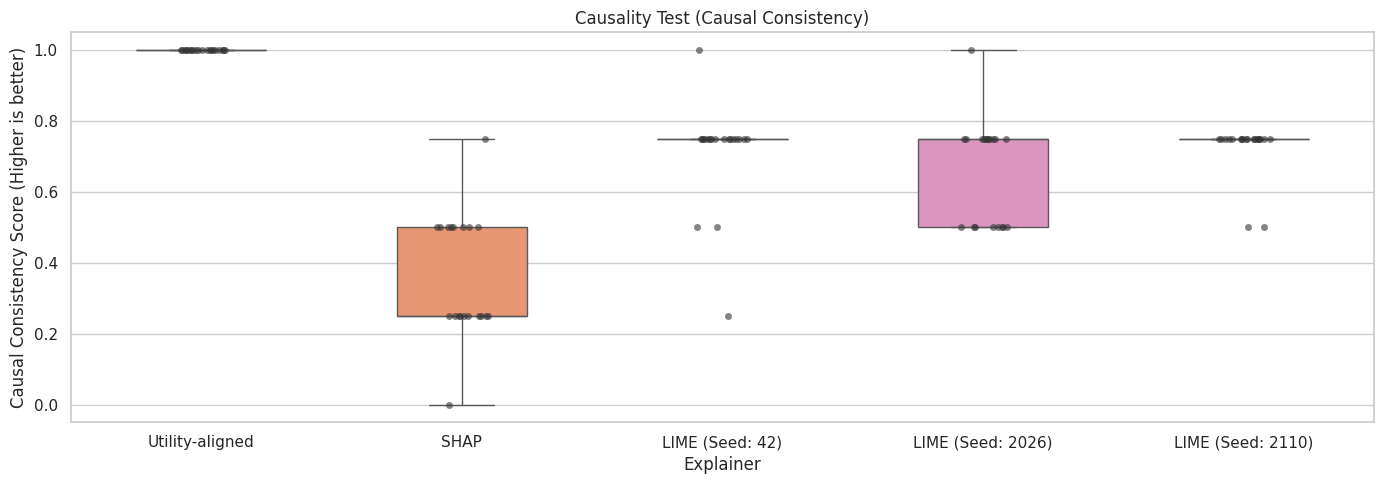

/home/alexis/UtilityAlignedExplainer/decision_maker.py:625: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Explainer", y="Utility Score", palette="Set2", showfliers=False, width=0.5)


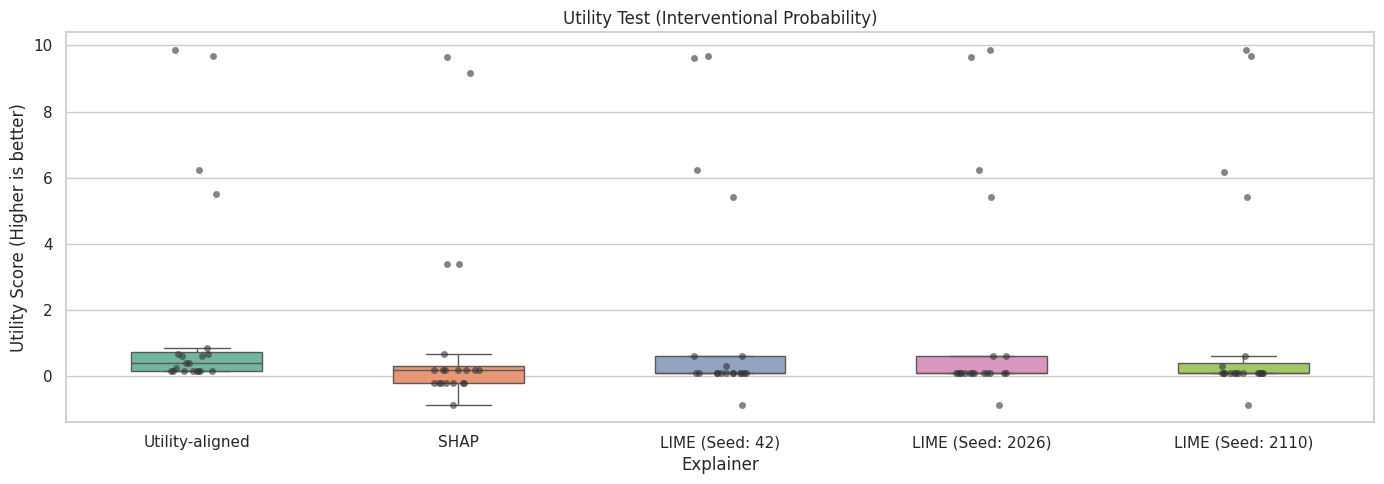

/home/alexis/UtilityAlignedExplainer/decision_maker.py:655: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Explainer", y="Fairness Score", palette="Set2", showfliers=False, width=0.5)


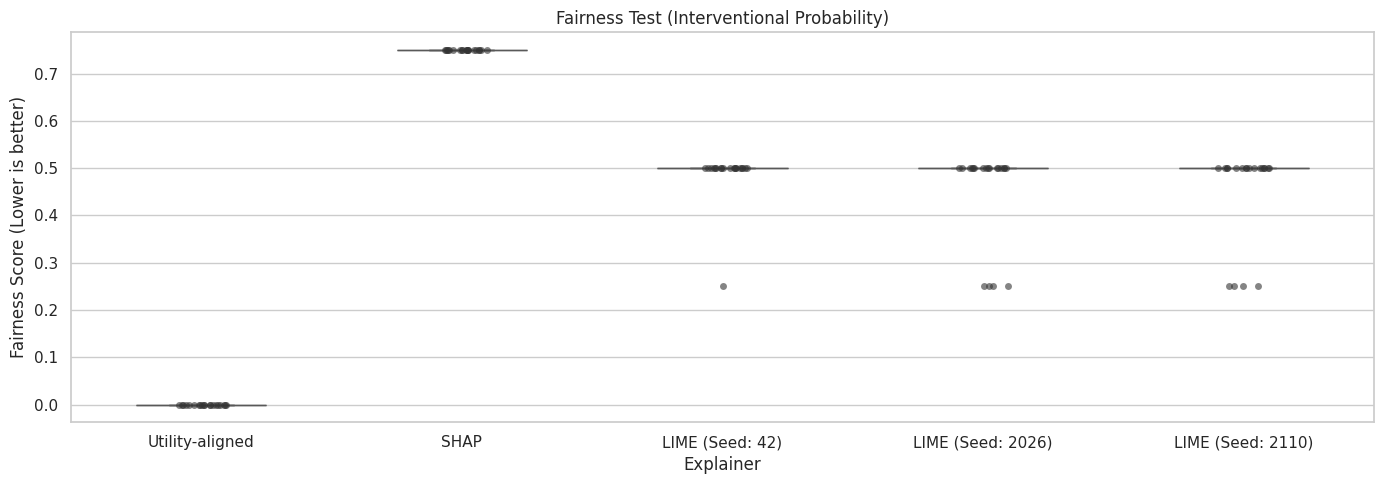

{'fidelity': ({'Local MORF': [np.float32(0.0),
    np.float32(-0.40554702),
    np.float32(0.37153456),
    np.float32(0.0),
    np.float32(-0.004876673),
    np.float32(0.12426621),
    np.float32(0.0),
    np.float32(0.0),
    np.float32(0.0),
    np.float32(0.0),
    np.float32(0.01214391),
    np.float32(0.0),
    np.float32(0.0),
    np.float32(-0.09364605),
    np.float32(-0.1659773),
    np.float32(0.0),
    np.float32(0.0),
    np.float32(0.06942332),
    np.float32(0.0),
    np.float32(0.0)],
   'Local LOCO': [np.float32(-0.0014061928),
    np.float32(-0.085234284),
    np.float32(-0.017150879),
    np.float32(0.004437566),
    np.float32(-0.0037068129),
    np.float32(0.04481232),
    np.float32(-0.0015566945),
    np.float32(6.645918e-05),
    np.float32(-0.004134476),
    np.float32(-0.013405263),
    np.float32(0.13892132),
    np.float32(-0.00102216),
    np.float32(0.06306255),
    np.float32(-0.09870559),
    np.float32(0.099699676),
    np.float32(0.0005610585),
    np

In [28]:
adult_tester3.do_all_tests(["Sex", "Race", "Country", "Marital_status"], display=True)

### Causal case 2: Ideal equality

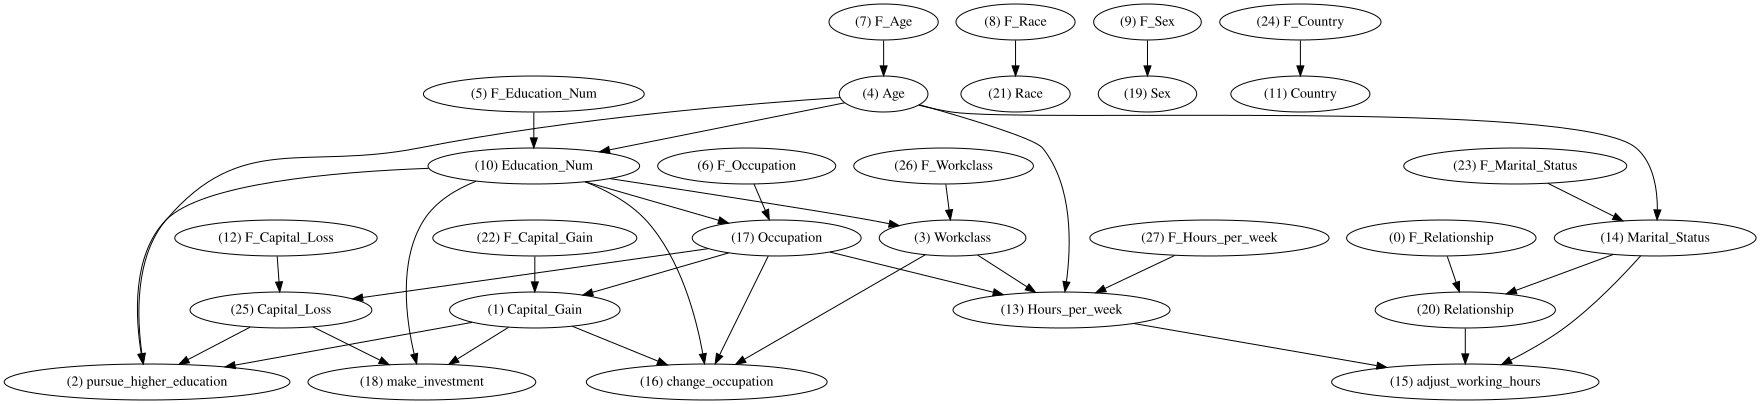

In [29]:
adult_causal_2 = CausalModel(features=adult_features, actions=adult_actions)
adult_causal_2.add_causal_edge('Age', 'Education_Num')
adult_causal_2.add_causal_edge('Age', 'Marital_Status')
adult_causal_2.add_causal_edge('Age', 'Hours_per_week')
#adult_causal_2.add_causal_edge('Country', 'Education_Num')
#adult_causal_2.add_causal_edge('Race', 'Education_Num')
#adult_causal_2.add_causal_edge('Sex', 'Occupation')
adult_causal_2.add_causal_edge('Education_Num', 'Occupation')
adult_causal_2.add_causal_edge('Education_Num', 'Workclass')
adult_causal_2.add_causal_edge('Marital_Status', 'Relationship')
adult_causal_2.add_causal_edge('Occupation', 'Hours_per_week')
adult_causal_2.add_causal_edge('Occupation', 'Capital_Gain')
adult_causal_2.add_causal_edge('Occupation', 'Capital_Loss')
#adult_causal_2.add_causal_edge('Race', 'Workclass')
adult_causal_2.add_causal_edge('Workclass', 'Hours_per_week')
adult_causal_2.add_causal_edge('Age', 'pursue_higher_education')
adult_causal_2.add_causal_edge('Education_Num', 'pursue_higher_education')
adult_causal_2.add_causal_edge('Capital_Gain', 'pursue_higher_education')
adult_causal_2.add_causal_edge('Capital_Loss', 'pursue_higher_education')
adult_causal_2.add_causal_edge('Occupation', 'change_occupation')
adult_causal_2.add_causal_edge('Education_Num', 'change_occupation')
adult_causal_2.add_causal_edge('Workclass', 'change_occupation')
adult_causal_2.add_causal_edge('Capital_Gain', 'change_occupation')
adult_causal_2.add_causal_edge('Hours_per_week', 'adjust_working_hours')
adult_causal_2.add_causal_edge('Marital_Status', 'adjust_working_hours')
adult_causal_2.add_causal_edge('Relationship', 'adjust_working_hours')
adult_causal_2.add_causal_edge('Capital_Gain', 'make_investment')
adult_causal_2.add_causal_edge('Capital_Loss', 'make_investment')
adult_causal_2.add_causal_edge('Education_Num', 'make_investment')
dag = adult_causal_2.getDAG()
adult_dot = dag.toDot()
adult_graph = graphviz.Source(adult_dot)
display(adult_graph)

#### Model 1: `RandomForestClassifier`

In [30]:
adult_lime_explainers = dict()

for seed in used_seeds:
    adult_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_adult.values,
        feature_names=adult_features,
        class_names=adult_class_names, 
#        categorical_features=adult_categorical_indices,
#        discretize_continuous=False,
        random_state=seed
    )
    adult_lime_explainers[seed] = adult_lime_explainer
adult_shap_explainer = shap.Explainer(adult_model1)

adult_tester1 = HeuristicExplainerTester(
    model=adult_model1,
    features=adult_features,
    actions=adult_actions,
    causal_model=adult_causal_2,
    utility_matrix=adult_utility_matrix,
    X_train=X_train_adult,
    y_train=y_train_adult,
    X_test=X_test_adult,
    lime_explainers=adult_lime_explainers,
    shap_explainer=adult_shap_explainer,
    n_samples=5
)

model_performance(adult_model1, X_test_adult, y_test_adult)

{'accuracy': 0.8378627360663289,
 'logloss': 0.3375156001104846,
 'roc_auc': 0.9203442942589801}

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

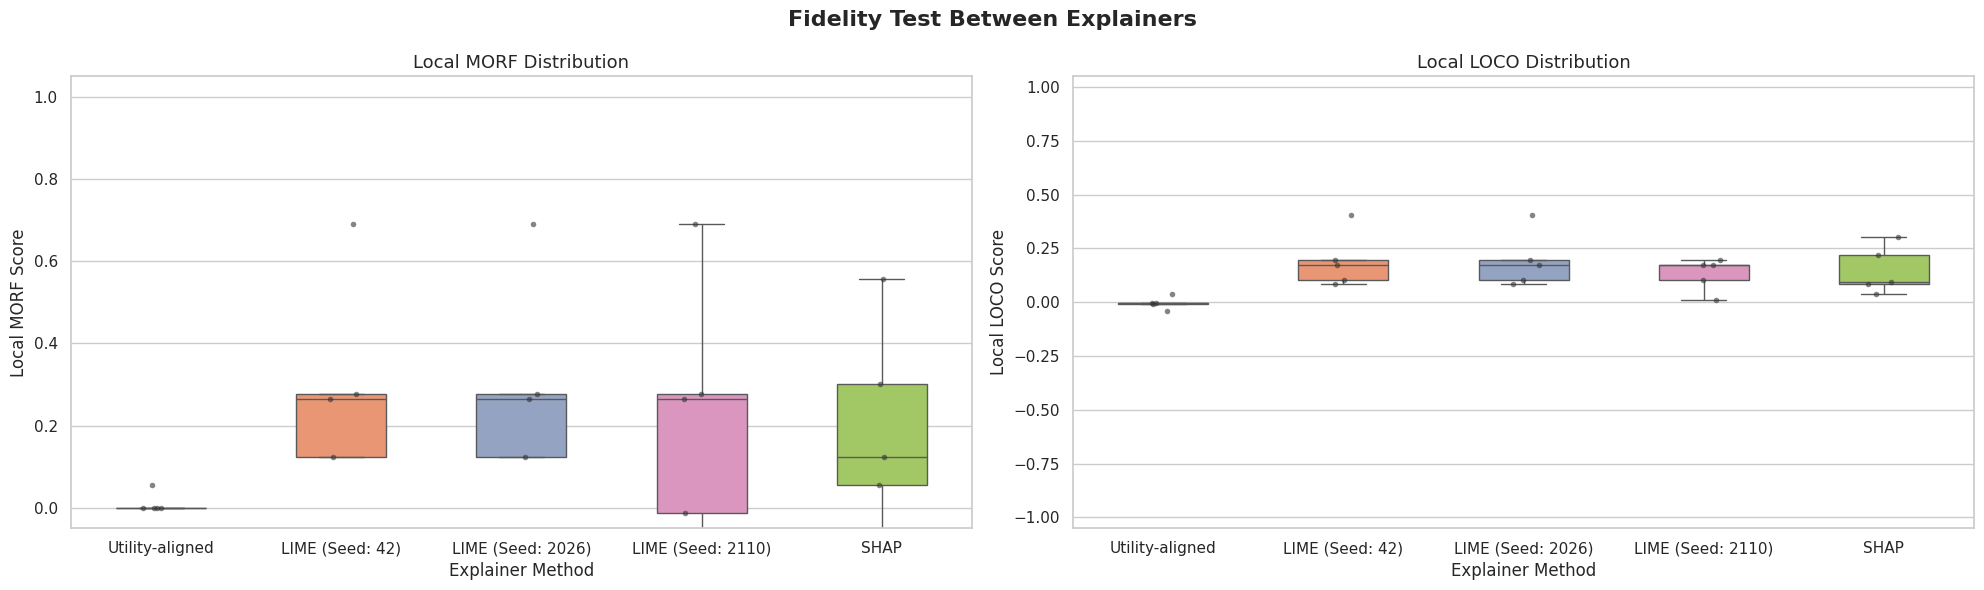

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

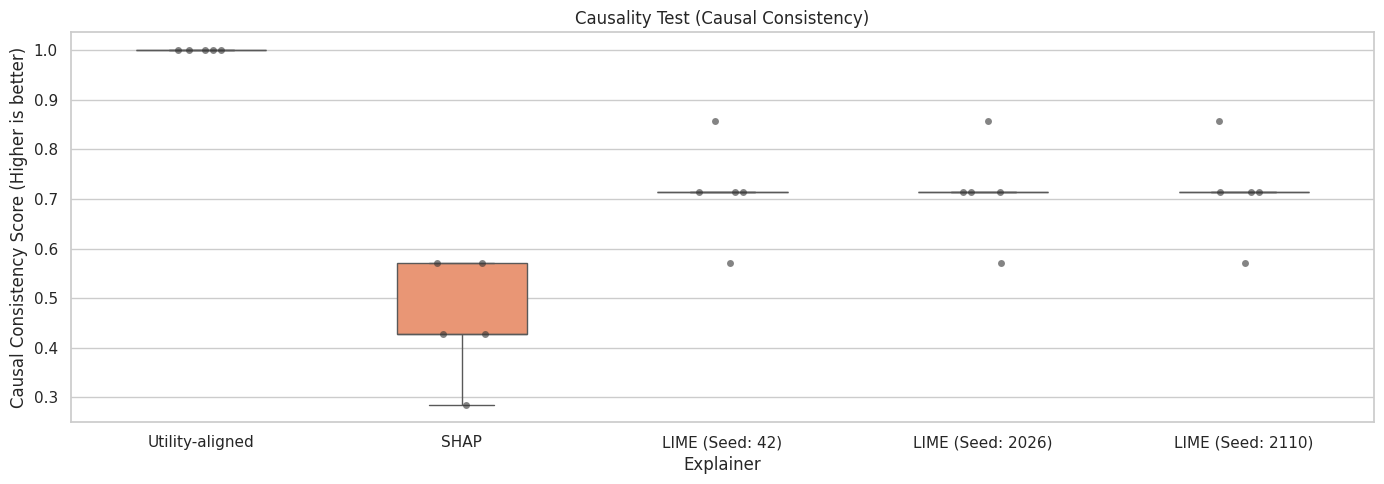

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

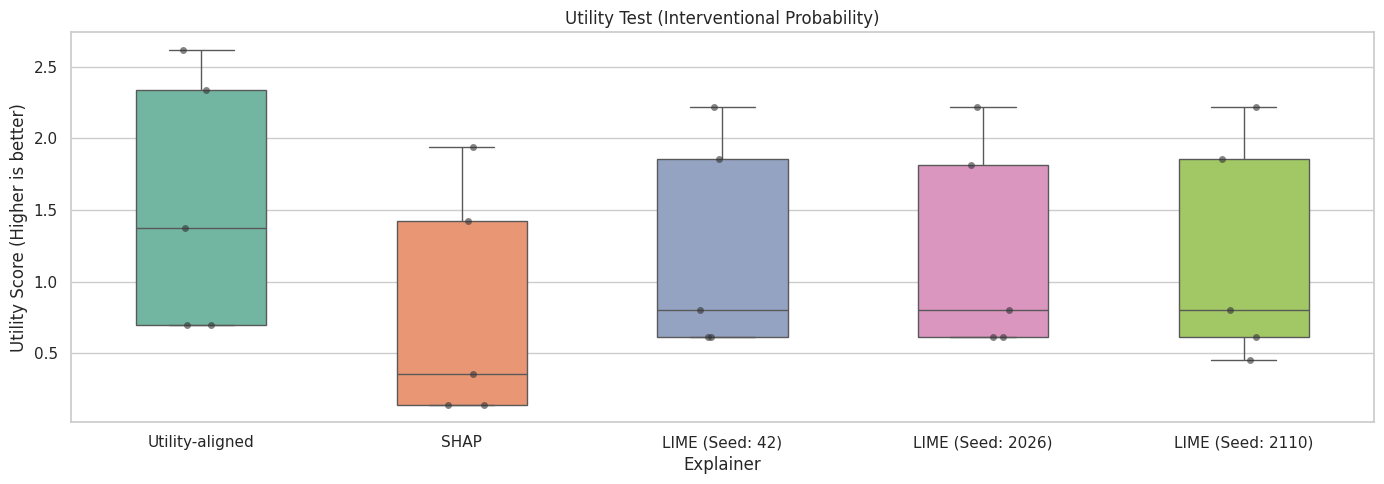

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

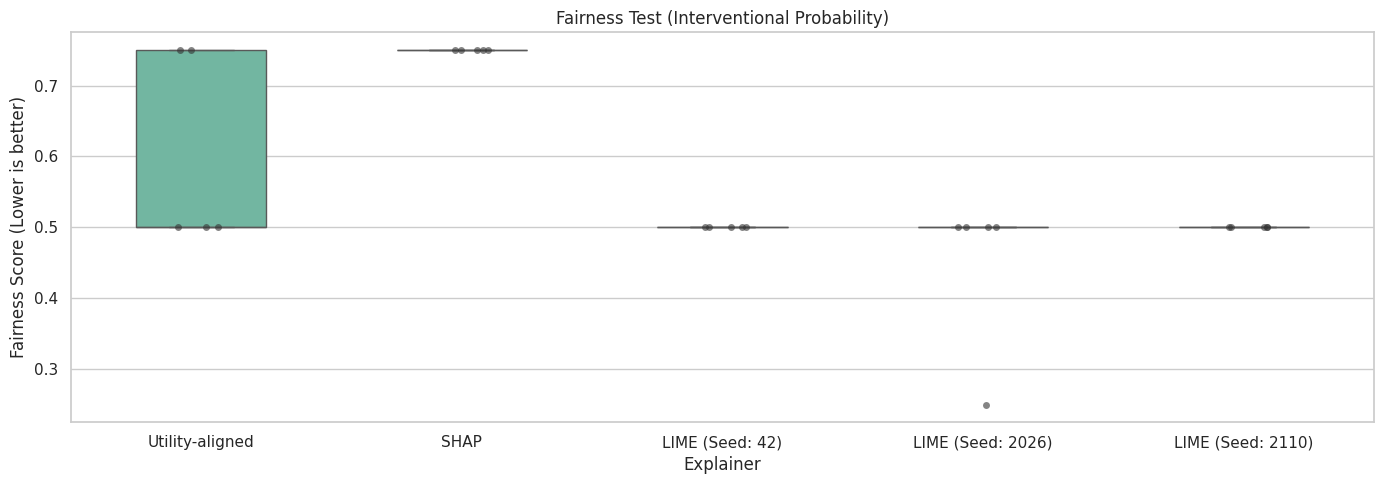

{'fidelity': ({'Local MORF': [np.float64(0.0),
    np.float64(0.055898463948481636),
    np.float64(1.1102230246251565e-16),
    np.float64(0.0),
    np.float64(0.0)],
   'Local LOCO': [np.float64(-0.004887049374537877),
    np.float64(0.03953328688384106),
    np.float64(-0.00848329168372619),
    np.float64(-0.0011591782028359532),
    np.float64(-0.039402283524188175)]},
  {'LIME (Seed: 42)': {'Local MORF': [np.float64(0.2638268169167258),
     np.float64(0.27780743752028847),
     np.float64(0.6911144329870349),
     np.float64(0.12295905025542886),
     np.float64(-0.12732572171960221)],
    'Local LOCO': [np.float64(0.19668916858725305),
     np.float64(0.17357108929224774),
     np.float64(0.40583234905206184),
     np.float64(0.08383838959500334),
     np.float64(0.1050275234686826)]},
   'LIME (Seed: 2026)': {'Local MORF': [np.float64(0.2638268169167257),
     np.float64(0.2778074375202884),
     np.float64(0.6911144329870349),
     np.float64(0.12295905025542886),
     np.flo

In [31]:
adult_tester1.do_all_tests(["Sex", "Race", "Country", "Marital_status"], display=True)

#### Model 2: `DecisionTreeClassifier`

In [32]:
adult_lime_explainers = dict()

for seed in used_seeds:
    adult_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_adult.values,
        feature_names=adult_features,
        class_names=adult_class_names, 
#        categorical_features=adult_categorical_indices,
#        discretize_continuous=False,
        random_state=seed
    )
    adult_lime_explainers[seed] = adult_lime_explainer
adult_shap_explainer = shap.Explainer(adult_model2)

adult_tester2 = HeuristicExplainerTester(
    model=adult_model2,
    features=adult_features,
    actions=adult_actions,
    causal_model=adult_causal_2,
    utility_matrix=adult_utility_matrix,
    X_train=X_train_adult,
    y_train=y_train_adult,
    X_test=X_test_adult,
    lime_explainers=adult_lime_explainers,
    shap_explainer=adult_shap_explainer,
    n_samples=5
)

model_performance(adult_model2, X_test_adult, y_test_adult)

{'accuracy': 0.8220482112697681,
 'logloss': 5.818243152576052,
 'roc_auc': 0.7777645899306559}

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted w

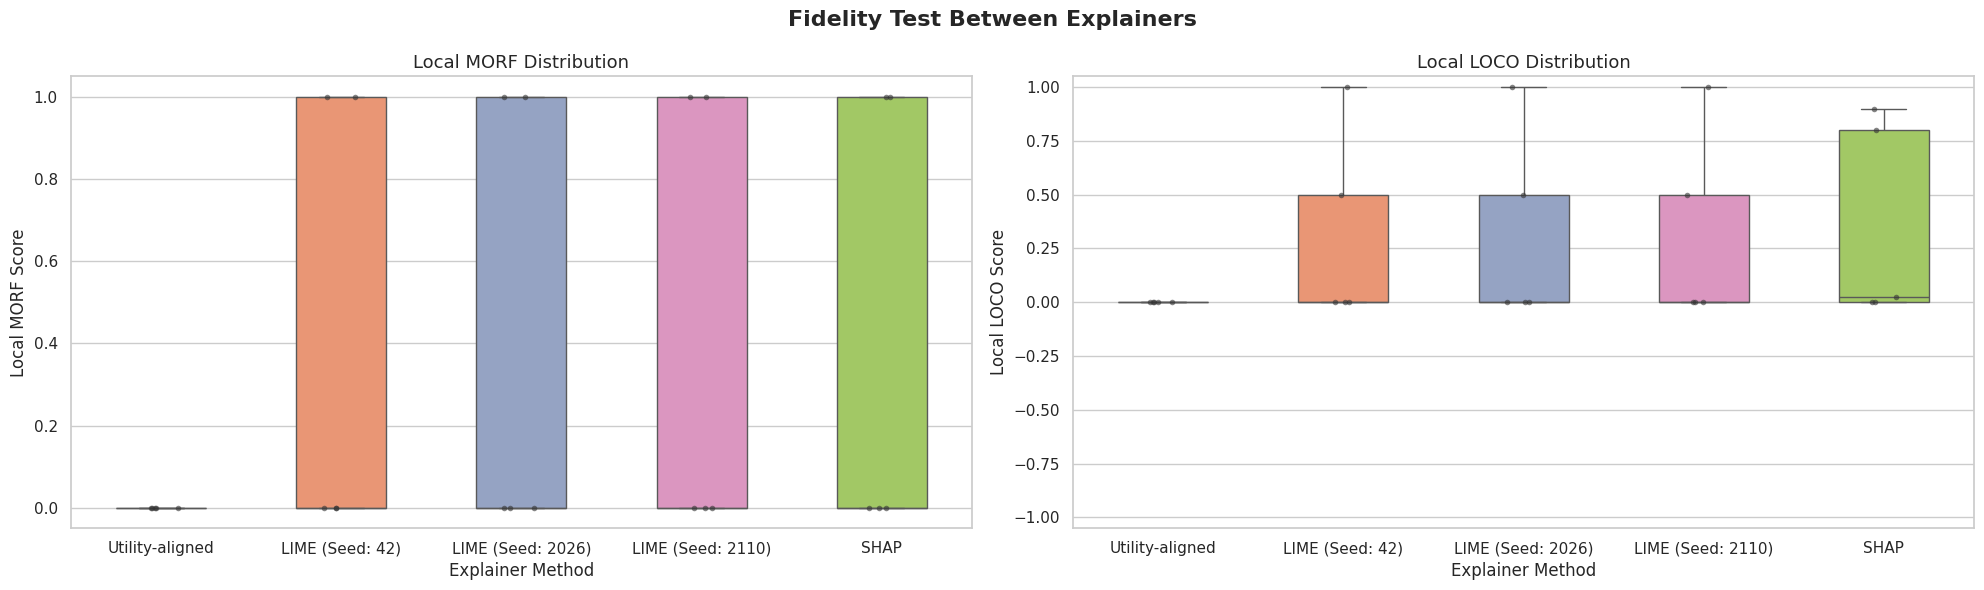

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted w

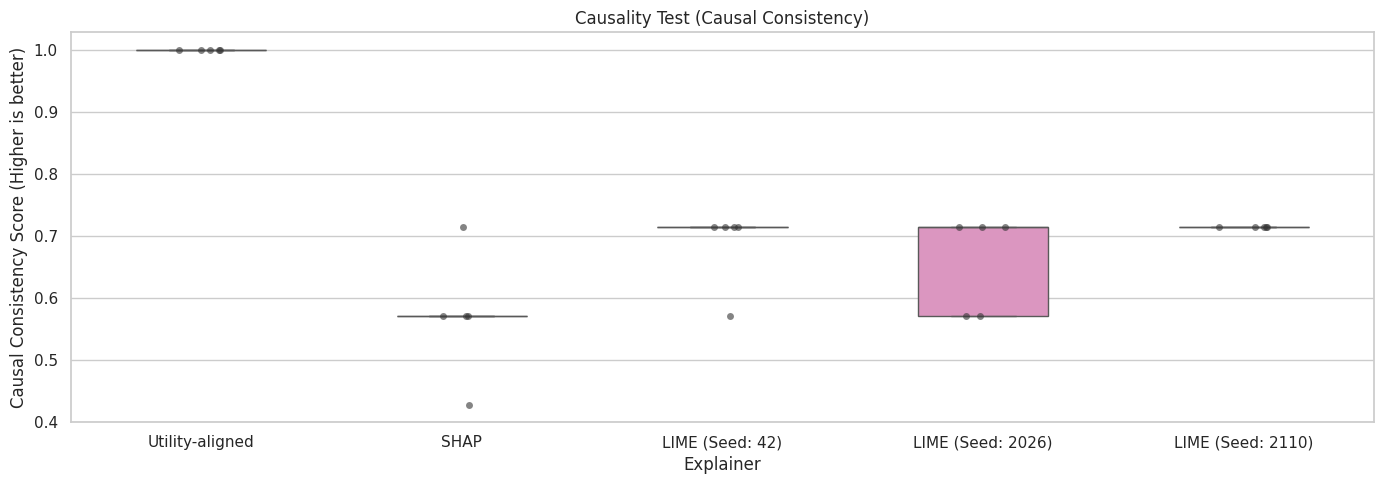

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted w

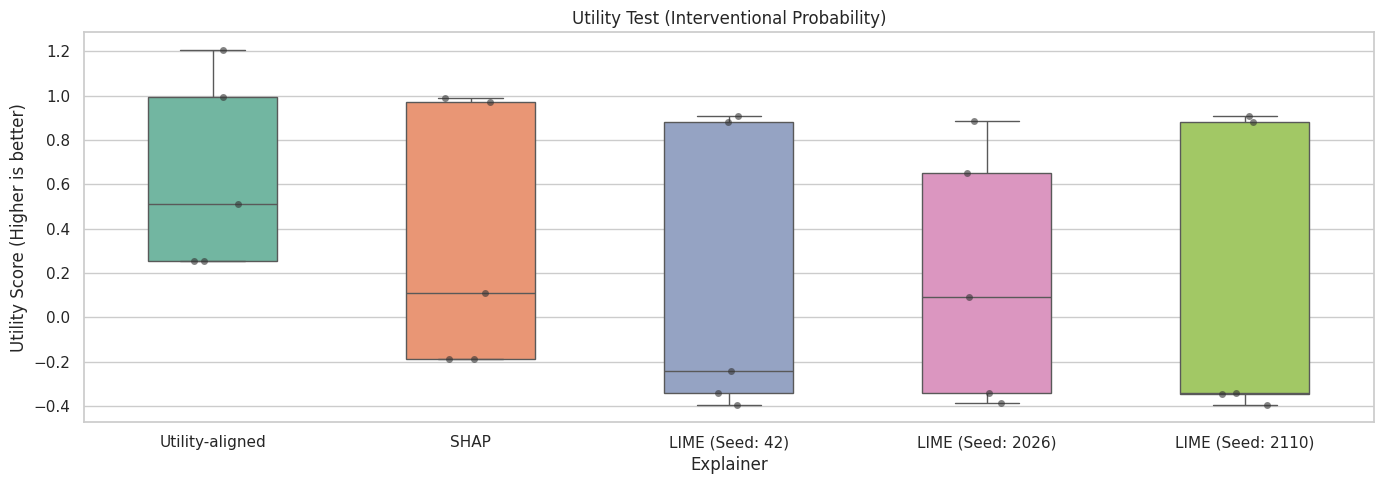

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted w

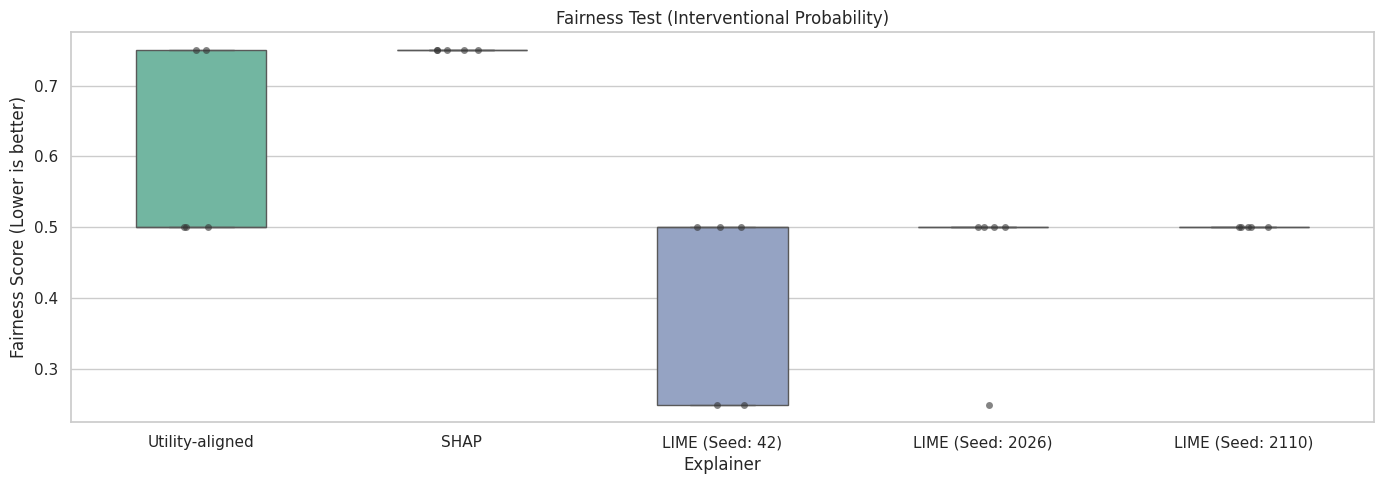

{'fidelity': ({'Local MORF': [np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0)],
   'Local LOCO': [np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0),
    np.float64(0.0)]},
  {'LIME (Seed: 42)': {'Local MORF': [np.float64(0.0),
     np.float64(1.0),
     np.float64(1.0),
     np.float64(0.0),
     np.float64(0.0)],
    'Local LOCO': [np.float64(0.0),
     np.float64(0.5),
     np.float64(1.0),
     np.float64(0.0),
     np.float64(0.0)]},
   'LIME (Seed: 2026)': {'Local MORF': [np.float64(0.0),
     np.float64(1.0),
     np.float64(1.0),
     np.float64(0.0),
     np.float64(0.0)],
    'Local LOCO': [np.float64(0.0),
     np.float64(0.5),
     np.float64(1.0),
     np.float64(0.0),
     np.float64(0.0)]},
   'LIME (Seed: 2110)': {'Local MORF': [np.float64(0.0),
     np.float64(1.0),
     np.float64(1.0),
     np.float64(0.0),
     np.float64(0.0)],
    'Local LOCO': [np.float64(0.0),
     np.float64(0.5),
 

In [33]:
adult_tester2.do_all_tests(["Sex", "Race", "Country", "Marital_status"], display=True)

#### Model 3: `XGBClassifier`

In [34]:
adult_lime_explainers = dict()

for seed in used_seeds:
    adult_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_adult.values,
        feature_names=adult_features,
        class_names=adult_class_names, 
#        categorical_features=adult_categorical_indices,
#        discretize_continuous=False,
        random_state=seed
    )
    adult_lime_explainers[seed] = adult_lime_explainer
adult_shap_explainer = shap.Explainer(adult_model3.predict, X_train_adult)

adult_tester3 = HeuristicExplainerTester(
    model=adult_model3,
    features=adult_features,
    actions=adult_actions,
    causal_model=adult_causal_2,
    utility_matrix=adult_utility_matrix,
    X_train=X_train_adult,
    y_train=y_train_adult,
    X_test=X_test_adult,
    lime_explainers=adult_lime_explainers,
    shap_explainer=adult_shap_explainer,
    n_samples=5
)

model_performance(adult_model3, X_test_adult, y_test_adult)

{'accuracy': 0.8759404268386304,
 'logloss': 0.275005520020763,
 'roc_auc': 0.9291614040501903}

/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:19:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:19:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:19:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:19:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/

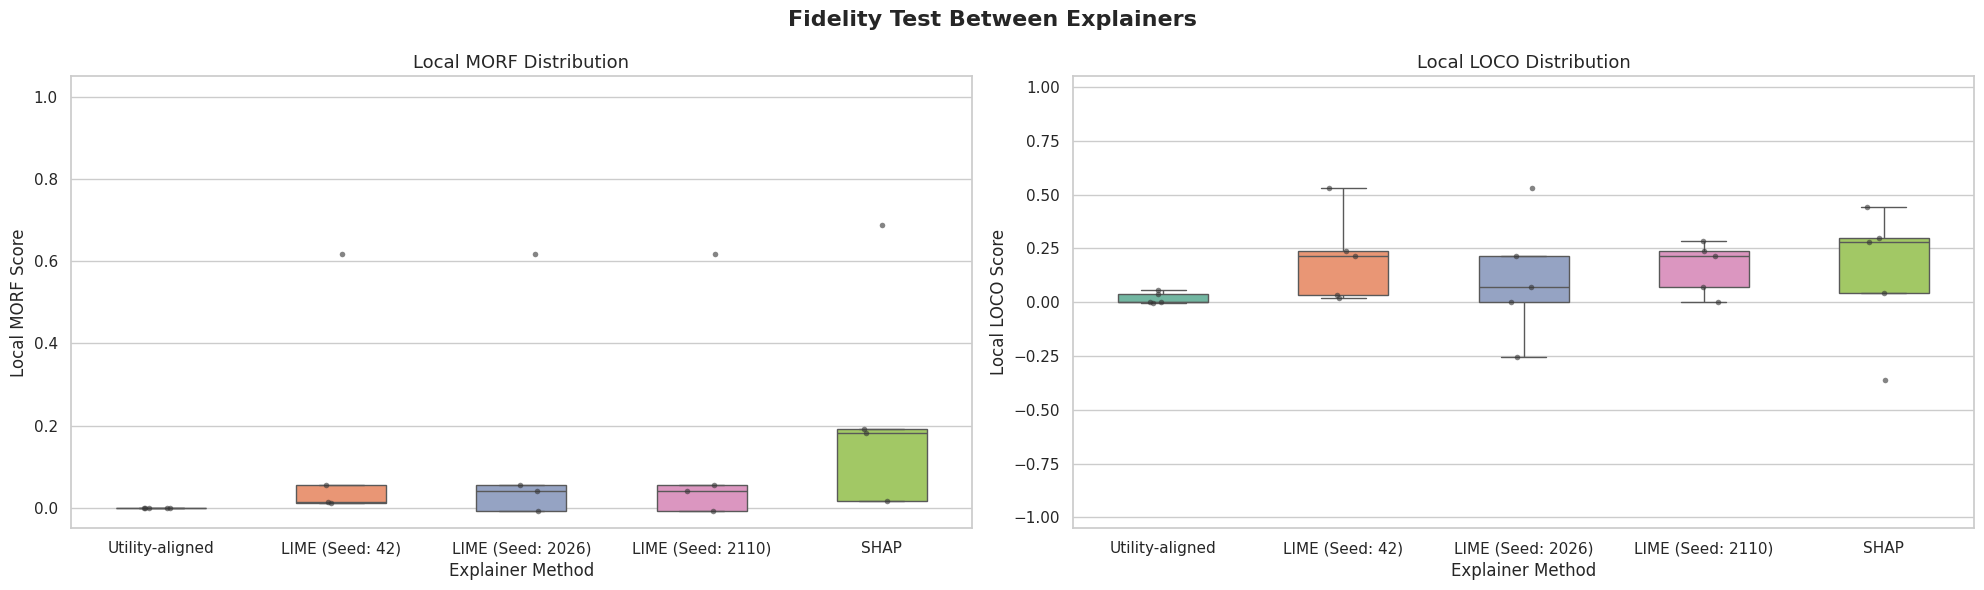

/home/alexis/UtilityAlignedExplainer/decision_maker.py:579: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Explainer", y="Causal Consistency Score", palette="Set2", showfliers=False, width=0.5)


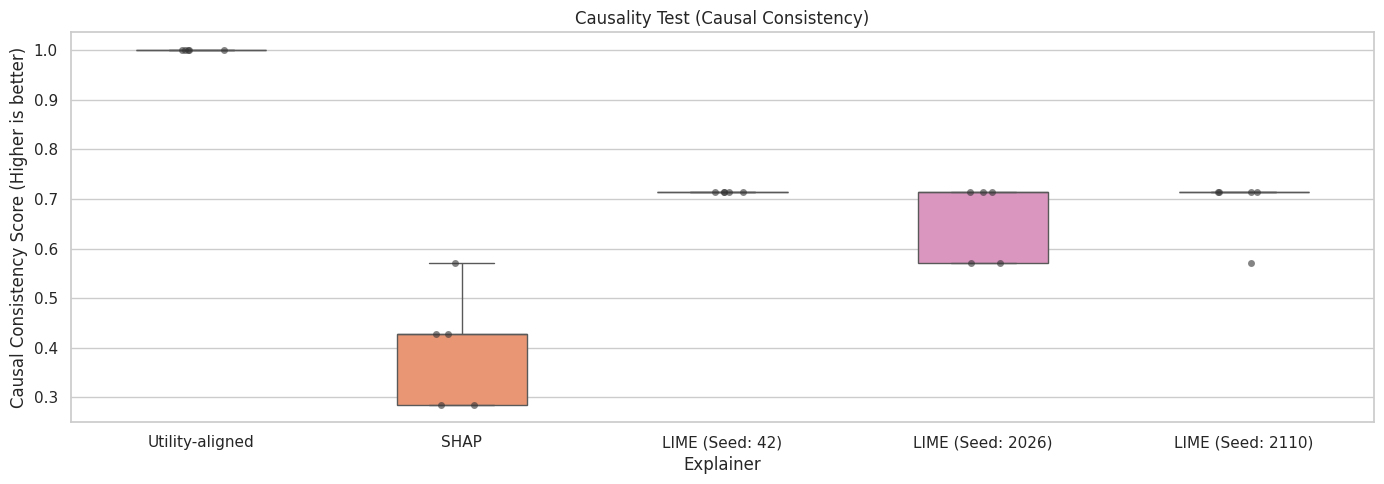

/home/alexis/UtilityAlignedExplainer/decision_maker.py:625: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Explainer", y="Utility Score", palette="Set2", showfliers=False, width=0.5)


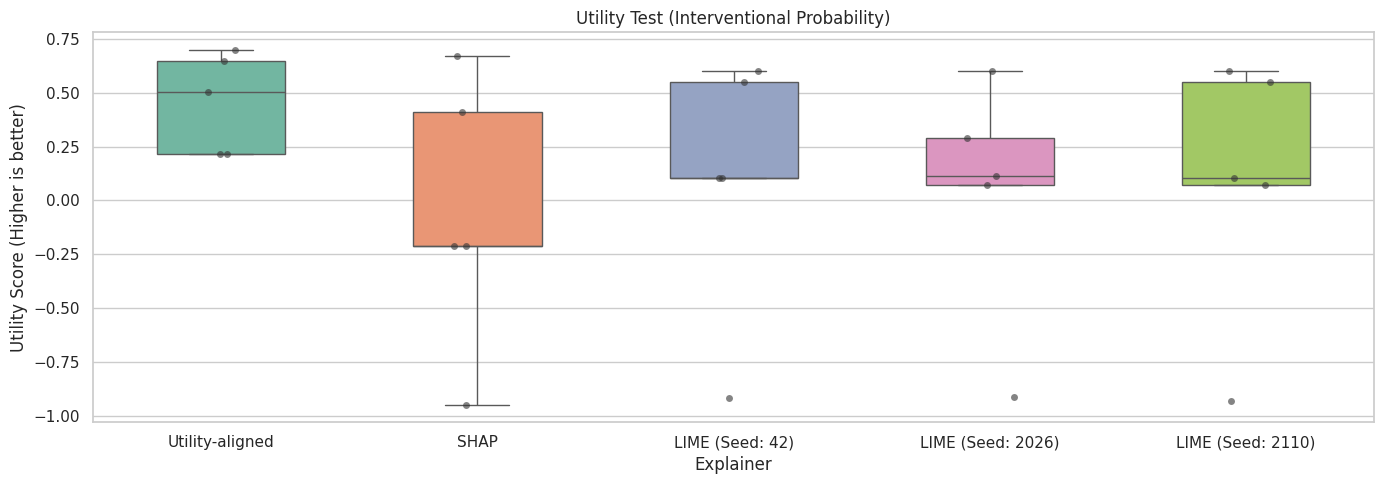

/home/alexis/UtilityAlignedExplainer/decision_maker.py:655: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Explainer", y="Fairness Score", palette="Set2", showfliers=False, width=0.5)


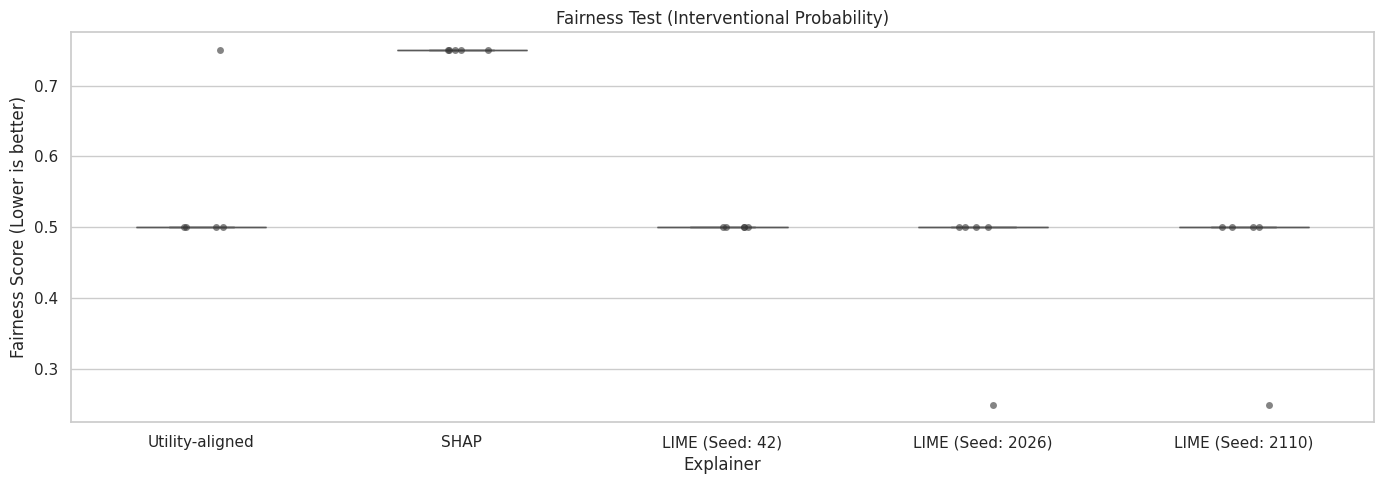

{'fidelity': ({'Local MORF': [np.float32(0.0),
    np.float32(0.0),
    np.float32(0.0),
    np.float32(0.0),
    np.float32(0.0)],
   'Local LOCO': [np.float32(-0.00086152554),
    np.float32(0.03846103),
    np.float32(0.056323647),
    np.float32(0.00034993887),
    np.float32(-0.0013065338)]},
  {'LIME (Seed: 42)': {'Local MORF': [np.float32(0.014282405),
     np.float32(-0.4016819),
     np.float32(0.6166108),
     np.float32(0.010507464),
     np.float32(0.05602318)],
    'Local LOCO': [np.float32(0.021270096),
     np.float32(0.23751724),
     np.float32(0.532922),
     np.float32(0.032064438),
     np.float32(0.21380526)]},
   'LIME (Seed: 2026)': {'Local MORF': [np.float32(0.039721012),
     np.float32(-0.4016819),
     np.float32(0.6166108),
     np.float32(-0.0069631934),
     np.float32(0.05602318)],
    'Local LOCO': [np.float32(0.07185763),
     np.float32(-0.25532442),
     np.float32(0.532922),
     np.float32(0.0031997561),
     np.float32(0.21380526)]},
   'LIME (Seed

In [35]:
adult_tester3.do_all_tests(["Sex", "Race", "Country", "Marital_status"], display=True)